# Lecture 1: Floating-point arithmetic, vector norms

## Syllabus

**Today:** 
- Part 1: floating point, vector norms
- Part 2: matrix norms and stability concepts



# Representation of numbers

- Real numbers are fundamental to mathematics and science, representing continuous quantities like:
    - Probabilities (between 0 and 1)
    - Physical measurements (mass, velocity, temperature, etc.)
    - Financial values (prices, interest rates)
    - Mathematical quantities (π, e, √2)

- The history of number systems dates back thousands of years:
    - Babylonians (2000 BCE) developed one of the first positional number systems
    - They used base-60 (sexagesimal) system, which influences how we measure time today
    - Their system could represent both whole numbers and fractions

<img src="misc/Babylonian_numerals.png" width=500>

- Modern computers can only process binary (base-2) numbers:
    - All data must be converted to sequences of 0s and 1s
    - This creates challenges for representing real numbers
    - We need efficient ways to encode both very large and very small numbers
    - Must balance precision, range, and memory usage
    - Understanding these representations is crucial for numerical computing and machine learning as well.

## Fixed Point Representation

 - Fixed point is the simplest way to represent real numbers digitally
   - Also known as **Qm.n** format, where:
     - m bits for the integer part
     - n bits for the fractional part

 - Key Properties:
   - Range: $[-(2^m), 2^m - 2^{-n}]$ 
   - Resolution: $2^{-n}$ (smallest representable difference)
   - Storage: $m + n + 1$ bits total (including sign bit)

 - Limitations:
   - Fixed range of representable numbers
   - Trade-off between range (m) and precision (n)
   - Cannot efficiently handle very large or very small numbers

# Floating point

The numbers in computer memory are typically represented as **floating point numbers**.

A floating point number is represented as:

$$\textrm{number} = \textrm{significand} \times \textrm{base}^{\textrm{exponent}},$$

where:
- *significand* is an integer
- *base* is a positive integer
- *exponent* is an integer (can be negative)

For example:

$$ 1.2 = 12 \cdot 10^{-1}.$$

This format has a long history. It was already used in the world's first working programmable, fully automatic digital computer [Z3](https://en.wikipedia.org/wiki/Z3_(computer)) designed in 1935 and completed in 1941 in Germany by [Konrad Zuse](https://en.wikipedia.org/wiki/Konrad_Zuse).

## Floating point: formula

$$f = (-1)^s 2^{(p-b)} \left( 1 + \frac{d_1}{2} + \frac{d_2}{2^2}  + \ldots + \frac{d_m}{2^m}\right),$$

where $s \in \{0, 1\}$ is the sign bit, $d_i \in \{0, 1\}$ is the $m$-bit mantissa, $p \in \mathbb{Z}; 0 \leq p \leq 2^e$, $e$ is the $e$-bit exponent, commonly defined as $2^e - 1$

Can be thought as a uniform $m$-bit grid between two sequential powers of $2$.

## Simple examples

There are many ways to write a number in scientific notation, but there is always a unique normalized representation, with exactly one non-zero digit to the left of the decimal point.
 
 For example:
 - $0.232 \times 10^3 = 23.2 \times 10^1 = 2.32 \times 10^2 = \ldots$
 - $01001 = 1.001 \times 2^3 = \ldots$
 
 **Example 1:** What's the normalized representation of $00101101.101$?

$0.0001101001110$ $= 1.110100111 \times 2^{-4}$

## Multiplication in more details

Consider two FP numbers $x, y$, whose exponents and fractions are $x_e, y_e$ and $x_m, y_m$ respectively, the vanilla FP Mul result is

$$
\operatorname{Mul}(x, y)=\left(1+x_m\right) \cdot 2^{x_e} \cdot\left(1+y_m\right) \cdot 2^{y_e}=\left(1+x_m+y_m+x_m \cdot y_m\right) \cdot 2^{x_e+y_e}
$$

Recent papers: [Addition is all you need](https://arxiv.org/pdf/2410.00907) tries to argue that we can replace this multplication by addition and still get trainable neural networks (needs to be checked.)


## Fixed vs Floating

**Q**: What are the advantages/disadvantages of the fixed and floating points?

**A**:  In most cases, they work just fine.

- However, fixed point represents numbers within specified range and controls **absolute** accuracy.

- Floating point represent numbers with **relative** accuracy, and is suitable for the case when numbers in the computations have varying scale (i.e., $10^{-1}$ and $10^{5}$).

- In practice, if speed is of no concern, use float32 or float64.

## Floating point numbers on a logarithmic scale
 
Let's visualize how floating point numbers are distributed on the real line:




Text(0.1, -0.05, 'Base (b) = $2$, Max exponent = $3$, Mantissa bits = $2$\nNumbers are of the form $(1 + x_m) \\cdot 2^e$, where $x_m$ is the fraction and $e$ is the exponent.')

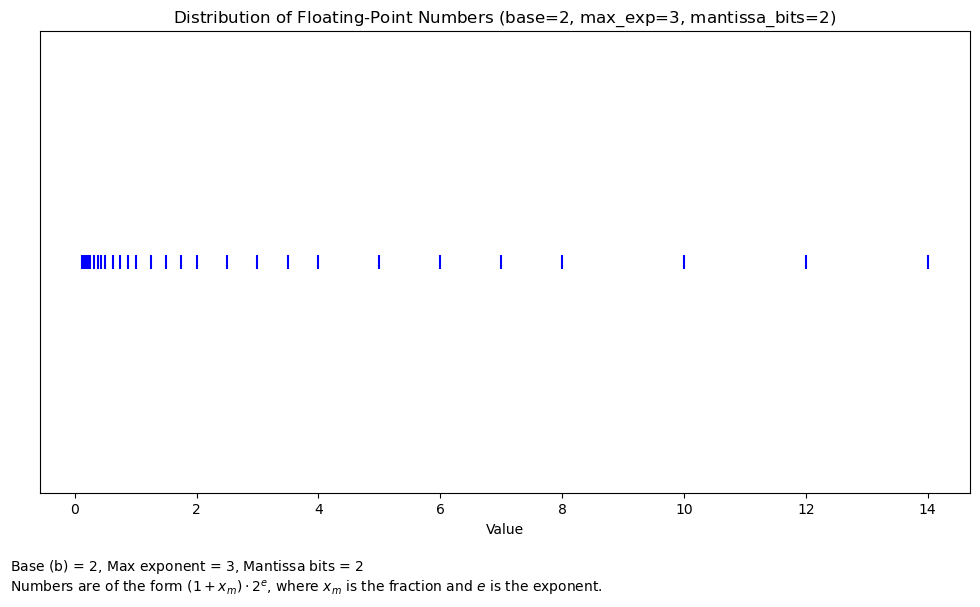

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters for a small floating-point system
b = 2  # base
e_max = 3  # maximum exponent
mantissa_bits = 2  # number of bits for mantissa

# Generate all possible combinations of exponent and mantissa
exponents = range(-e_max, e_max + 1)
mantissas = np.linspace(0, 1 - 2**(-mantissa_bits), 2**mantissa_bits)

# Calculate floating-point numbers
fp_numbers = []
for e in exponents:
    for m in mantissas:
        fp_numbers.append((1 + m) * b**(e))

# Sort the numbers for proper visualization
fp_numbers.sort()

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the floating-point numbers
ax.scatter(fp_numbers, [1] * len(fp_numbers), marker='|', s=100, color='blue')
ax.set_ylim(0.5, 1.5)
ax.set_yticks([])  # Remove y-axis ticks

ax.set_title(r'Distribution of Floating-Point Numbers (base=$%d$, max_exp=$%d$, mantissa_bits=$%d$)' % (b, e_max, mantissa_bits))
ax.set_xlabel('Value')

# Add text explanation
plt.figtext(0.1, -0.05, 
    r"Base (b) = $%d$, Max exponent = $%d$, Mantissa bits = $%d$" % (b, e_max, mantissa_bits) + "\n" +
    r"Numbers are of the form $(1 + x_m) \cdot 2^e$, where $x_m$ is the fraction and $e$ is the exponent.",
    wrap=True)
#plt.tight_layout()
#plt.show()

## IEEE 754
In modern computers, the floating point representation is controlled by [IEEE 754 standard](https://en.wikipedia.org/wiki/IEEE_floating_point) which was published in **1985** and before that point different computers behaved differently with floating point numbers. 

IEEE 754 has:
- Floating point representation (as described above), $(-1)^s \times c \times b^q$.
- Two infinities, $+\infty$ and $-\infty$
- Two zeros: +0 and -0
- Two kinds of **NaN**: a quiet NaN (**qNaN**) and signalling NaN (**sNaN**) 
    - qNaN does not throw exception in the level of floating point unit (FPU), until you check the result of computations
    - sNaN value throws exception from FPU if you use corresponding variable. This type of NaN can be useful for initialization purposes
    - C++11 proposes [standard interface](https://en.cppreference.com/w/cpp/numeric/math/nan) for creating different NaNs 
- Rules for **rounding**
- Rules for $\frac{0}{0}, \frac{1}{-0}, \ldots$

Possible values are defined with
- base $b$
- accuracy $p$ - number of digits
- maximum possible value $e_{\max}$

and have the following restrictions 
- $ 0 \leq c \leq b^p - 1$
- $1 - e_{\max} \leq q + p - 1 \leq e_{\max}$ 

##  Single precision, double precision

The two standard formats, called **binary32** and **binary64** (called also **single** and **double** formats). Recently, the format **binary16** plays important role in learning deep neural networks.

| Name | Common Name | Base | Digits | Emin | Emax |
|------|----------|----------|-------|------|------|
|binary16| half precision | 2 | 11 | -14 | + 15 |
|binary32| single precision | 2 | 24 | -126 | + 127 |  
|binary64| double precision | 2 | 53 | -1022 | +1023 |  

<img src="misc/double64.png">

## Examples

- For a number +0
    - *sign* is 0
    - *exponent* is 00000000000
    - *fraction* is all zeros
- For a number -0
    - *sign* is 1
    - *exponent* is 00000000000
    - *fraction* is all zeros
- For +infinity
    - *sign* is 0
    - *exponent* is 11111111111
    - *fraction* is all zeros

**Q**: what about -infinity and NaN ?

## Accuracy and memory

The **relative accuracy** of single precision is $10^{-7}-10^{-8}$, while for double precision is $10^{-14}-10^{-16}$.

<font color='red'> Crucial note 1: </font> A **float16** takes **2 bytes**, **float32** takes **4 bytes**, **float64**, or double precision, takes **8 bytes.**

<font color='red'> Crucial note 2: </font> These are the only two floating point-types supported in hardware (float32 and float64) + GPU/TPU different float types are supported.

<font color='red'> Crucial note 3: </font> You should use **double precision** in computational science and engineering and **float32/float16** on GPU/Data Science.

Now for large models float16 has become more and more robust.


## How does number representation format affect training of neural networks (NN)?

- Weights in layers (fully-connected, convolutional, activation functions) can be stored with different accuracies
- It is important to improve energy efficiency of the devices that are used to train NNs
- Project [DeepFloat](https://github.com/facebookresearch/deepfloat) from Facebook demonstrates how re-develop floating point operations in a way to ensure efficiency in training NNs, more details see in this [paper](https://arxiv.org/pdf/1811.01721.pdf)
- Affect of the real numbers representation on the gradients of activation functions
- Typically, the first digit is one.
- Subnormal numbers have first digit 0 to represent zeros and numbers close to zero.
- Subnormal numbers fill the gap between positive and negative
- They have performance issues, often flushed to zero by default.

<img width=500, src="misc/grad_norm_fp16.png">

- And on the learning curves

<img width=500, src="misc/train_val_curves.png">

Plots are taken from [this paper](https://arxiv.org/pdf/1710.03740.pdf%EF%BC%89%E3%80%82)

## bfloat16 (Brain Floating Point)

- This format occupies 16 bits
    - 1 bit for sign
    - 8 bits for exponent
    - 7 bits for fraction
    <img src="misc/bfloat16.png">
- Truncated single precision format from IEEE standard
- What is the difference between float32 and float16?
- This format is utilized in Intel FPGA, Google TPU, Xeon CPUs and other platforms

## Tensor Float from Nvidia ([blog post about this format](https://blogs.nvidia.com/blog/2020/05/14/tensorfloat-32-precision-format/))

- Comparison with other formats

<img src="misc/tensor_float_cf.png">

- Results

<img src="misc/TF32-BERT.png">

- PyTorch and Tensorflow supported this format are available in [Nvidia NCG](https://ngc.nvidia.com/catalog/all)

## Mixed precision ([docs from Nvidia](https://docs.nvidia.com/deeplearning/performance/mixed-precision-training/index.html))

- Main idea:
    - Maintain copy of weights in single precision
    - Then in every iteration
        - Make a copy of weights in half-precision
        - Forward pass with weights in half-precision
        - Multiply the loss by the scaling factor $S$
        - Backward pass again in half precision
        - Multiply the weight gradient with $1/S$
        - Complete the weight update (including gradient clipping, etc.)
    - Scaling factor $S$ is a hyper-parameter
    - Constant: a value so that its product with the maximum absolute gradient value is below 65504 (the maximum value representable in half precision).
    - Dynamic update based on the current gradient statistics
- Performance comparison
<img src="misc/mixed_precision_res.png" width=500>

- Automatic mixed-precision extensions exist to simplify turning this option on, more details [here](https://developer.nvidia.com/automatic-mixed-precision)

## Alternative to the IEEE 754 standard

Issues in IEEE 754:
- overflow to infinity or zero
- many different NaNs
- invisible rounding errors
- accuracy is very high or very poor
- subnormal numbers – numbers between 0 and minimal possible represented number, i.e. significand starts from zero

Concept of **posits** can replace floating point numbers, see [this paper](http://www.johngustafson.net/pdfs/BeatingFloatingPoint.pdf)

<img width=600 src="misc/posit.png">

- represent numbers with some accuracy, but provide limits of changing
- no overflows!
- example of a number representation 

<img width=600 src="misc/posit_example.png">

### Division accuracy demo

In [3]:

import random
import numpy as np
c = np.float32(6876.925924589693)
print(c)
a = np.float32(1.786875867457e-2)
b = np.float32(c / a)
print('{0:10.16f}'.format(b))
print(abs(a * b - c)/abs(c))

6876.926
384857.5000000000000000
0.0


### Square root accuracy demo

In [9]:
a = np.float32(1e-20)
b = np.sqrt(a)
print(b.dtype)
print('{0:10.64f}'.format(abs(b * b - a)/abs(a)))

float32
0.0000000807793583135207882151007652282714843750000000000000000000


### Exponent accuracy demo

In [14]:
a = np.float64(0.000001)
b = np.exp(a)
print(b.dtype)
print((np.log(b) - a)/a)

float64
-3.798286317901415e-11


## More complicated example

/var/folders/x_/_k8z8m6s2qxc_j4gwz6fpvmm0000gp/T/ipykernel_68783/1439480773.py:12: RuntimeWarning: invalid value encountered in divide
  y_b[nonzero] = (np.log(x[nonzero]+1))/((1+x[nonzero])-1) - 1  # (b


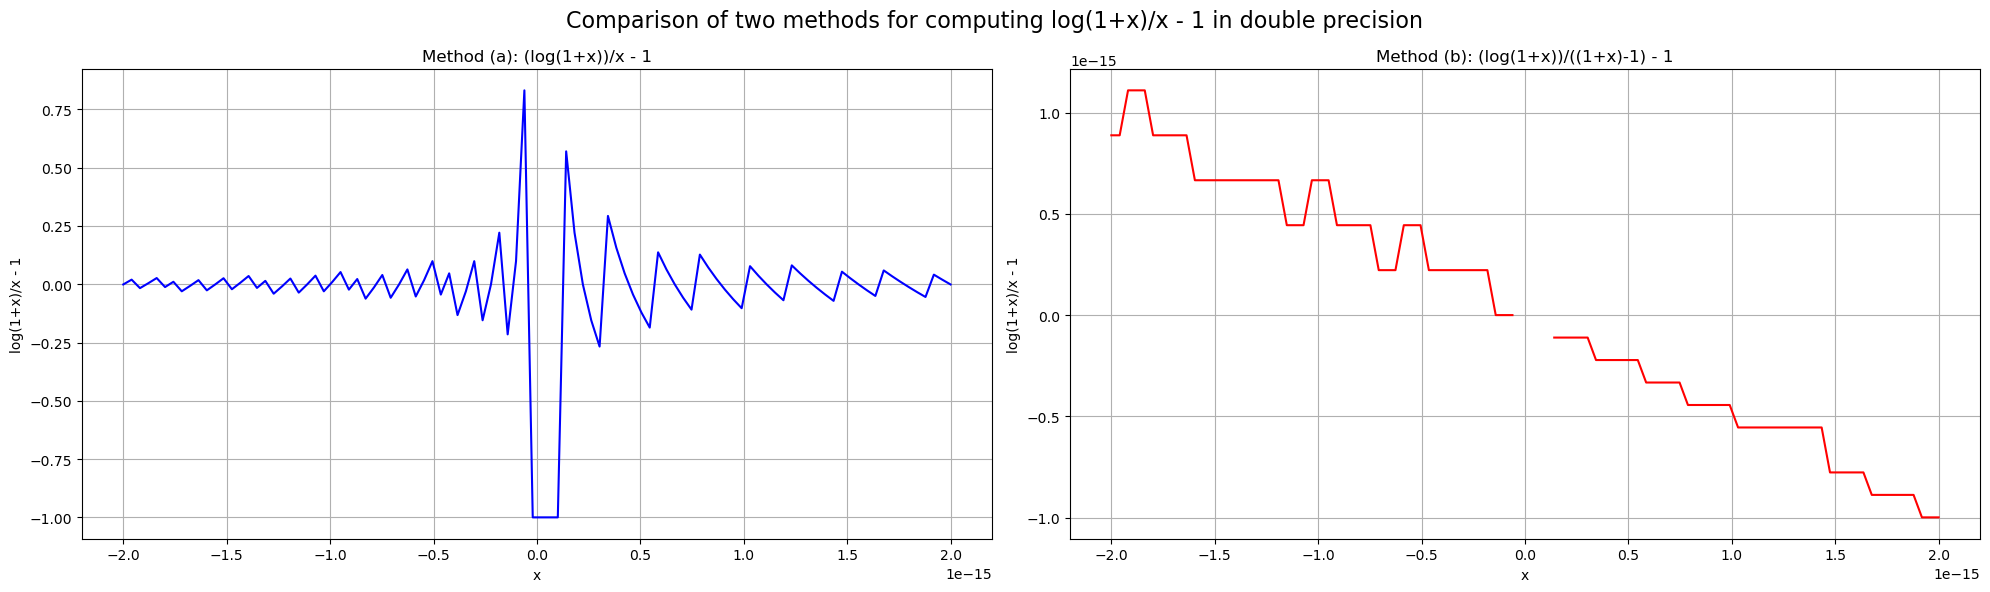

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Create x points in the range [-2e-15, 2e-15]
x = np.linspace(-2e-15, 2e-15, 100)

# Compute log(1+x)/x - 1 using method (a) and (b), being careful about x=0
y_a = np.zeros_like(x)
y_b = np.zeros_like(x)
nonzero = x != 0
y_a[nonzero] = (np.log(x[nonzero]+1))/x[nonzero] - 1  # (a)
y_b[nonzero] = (np.log(x[nonzero]+1))/((1+x[nonzero])-1) - 1  # (b

# Create the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot for method (a)
ax1.plot(x, y_a, 'b-')
ax1.grid(True)
ax1.set_xlabel('x')
ax1.set_ylabel('log(1+x)/x - 1')
ax1.set_title('Method (a): (log(1+x))/x - 1')

# Plot for method (b)
ax2.plot(x, y_b, 'r-')
ax2.grid(True)
ax2.set_xlabel('x')
ax2.set_ylabel('log(1+x)/x - 1')
ax2.set_title('Method (b): (log(1+x))/((1+x)-1) - 1')

# Adjust layout and add a main title
plt.tight_layout()
fig.suptitle('Comparison of two methods for computing log(1+x)/x - 1 in double precision', fontsize=16)
plt.subplots_adjust(top=0.88)

plt.show()

## Summary of demos

- For some values the inverse functions give exact answers
- The relative accuracy should be preserved due to the IEEE standard
- Does not hold for many modern GPU
- More details about adoptation of IEEE 754 standard for GPU you can find [here](https://docs.nvidia.com/cuda/floating-point/index.html#considerations-for-heterogeneous-world) 

## Loss of significance

- Many operations lead to the loss of digits [loss of significance](https://en.wikipedia.org/wiki/Loss_of_significance)
- For example, it is a bad idea to subtract two big numbers that are close, the difference will have fewer correct digits
- This is related to algorithms and their properties (forward/backward stability), which we will discuss later

## Summation algorithm

However, the rounding errors can depend on the algorithm.

- Consider the simplest problem: given $n$ floating point numbers $x_1, \ldots, x_n$  

- Compute their sum

$$S = \sum_{i=1}^n x_i = x_1 + \ldots + x_n.$$

- The simplest algorithm is to add one-by-one 

- What is the actual error for such algorithm? 

## Na&iuml;ve algorithm

Na&iuml;ve algorithm adds numbers one-by-one: 

$$y_1 = x_1, \quad y_2 = y_1 + x_2, \quad y_3 = y_2 + x_3, \ldots.$$

- The **worst-case** error is then proportional to $\mathcal{O}(n)$, while **mean-squared** error is $\mathcal{O}(\sqrt{n})$.

- The **Kahan algorithm** gives the worst-case error bound $\mathcal{O}(1)$ (i.e., independent of $n$).  

- <font color='red'> Can you find the better algorithm?

## Kahan summation
The following algorithm gives $2 \varepsilon + \mathcal{O}(n \varepsilon^2)$ error, where $\varepsilon$ is the machine precision.

- The reason of the loss of significance in summation is operating with numbers of different magnitude
- The main idea of Kahan summation is to keep track of small errors and aggregate them in separate variable
- This approach is called *compensated summation*

```python
s = 0
c = 0
for i in range(len(x)):
    y = x[i] - c
    t = s + y
    c = (t - s) - y
    s = t
```

- There exists more advanced tricks to process this simple operation that are used for example in ```fsum``` function from ```math``` package, implementation check out [here](https://github.com/python/cpython/blob/d267006f18592165ed97e0a9c2494d3bce25fc2b/Modules/mathmodule.c#L1087)  

In [5]:
import math

import jax.numpy as jnp
import numpy as np
import jax
from numba import jit as numba_jit

n = 10 ** 5
sm = 1e-10
x = jnp.ones(n, dtype=jnp.float32) * sm
x = x.at[0].set(1)
#x = jax.ops.index_update(x, [0], 1.)
true_sum = 1.0 + (n - 1)*sm
approx_sum = jnp.sum(x)
math_fsum = math.fsum(x)


@jax.jit
def dumb_sum(x):
    s = jnp.float32(0.0)
    def b_fun(i, val):
        return val + x[i] 
    s = jax.lax.fori_loop(0, len(x), b_fun, s)
    return s


@numba_jit(nopython=True)
def kahan_sum_numba(x):
    s = np.float32(0.0)
    c = np.float32(0.0)
    for i in range(len(x)):
        y = x[i] - c
        t = s + y
        c = (t - s) - y
        s = t
    return s

@jax.jit
def kahan_sum_jax(x):
    s = jnp.float32(0.0)
    c = jnp.float32(0.0)
    def b_fun2(i, val):
        s, c = val
        y = x[i] - c
        t = s + y
        c = (t - s) - y
        s = t
        return s, c
    s, c = jax.lax.fori_loop(0, len(x), b_fun2, (s, c))
    return s

k_sum_numba = kahan_sum_numba(np.array(x))
k_sum_jax = kahan_sum_jax(x)
d_sum = dumb_sum(x)
print('Error in np sum: {0:3.1e}'.format(approx_sum - true_sum))
print('Error in Kahan sum Numba: {0:3.1e}'.format(k_sum_numba - true_sum))
print('Error in Kahan sum JAX: {0:3.1e}'.format(k_sum_jax - true_sum))
print('Error in dumb sum: {0:3.1e}'.format(d_sum - true_sum))
print('Error in math fsum: {0:3.1e}'.format(math_fsum - true_sum))

Error in np sum: 0.0e+00
Error in Kahan sum Numba: 1.4e-08
Error in Kahan sum JAX: 0.0e+00
Error in dumb sum: -1.0e-05
Error in math fsum: 1.3e-13


## Summary of floating-point 
- You should be really careful with floating point numbers, since it may give you incorrect answers due to rounding-off errors.

- For many standard algorithms, the stability is well-understood and problems can be easily detected.

## Vectors
- In NLA we typically work not with **numbers**, but with **vectors**
- Recall that a vector in a fixed basis of size $n$ can be represented as a 1D array with $n$ numbers 
- Typically, it is considered as an $n \times 1$ matrix (**column vector**)

**Example:** 
Polynomials with degree $\leq n$ form a linear space. 
Polynomial $ x^3 - 2x^2 + 1$ can be considered as a vector $\begin{bmatrix}1 \\ -2 \\ 0 \\ 1\end{bmatrix}$ in the basis $\{x^3, x^2, x, 1\}$

## Vector norm

- Vectors typically provide an (approximate) description of a physical (or some other) object 

- One of the main question is **how accurate** the approximation is (1%, 10%)

- What is an acceptable representation, of course, depends on the particular applications. For example:
    - In partial differential equations accuracies $10^{-5} - 10^{-10}$ are the typical case
    - In data-based applications sometimes an error of $80\%$ is ok, since the interesting signal is corrupted by a huge noise

## Distances and norms

- Norm is a **qualitative measure of smallness of a vector** and is typically denoted as $\Vert x \Vert$.

The norm should satisfy certain properties:

- $\Vert \alpha x \Vert = |\alpha| \Vert x \Vert$
- $\Vert x + y \Vert \leq \Vert x \Vert + \Vert y \Vert$ (triangle inequality)
- If $\Vert x \Vert = 0$ then $x = 0$

The distance between two vectors is then defined as

$$ d(x, y) = \Vert x - y \Vert. $$

## Standard norms
The most well-known and widely used norm is **euclidean norm**:

$$\Vert x \Vert_2 = \sqrt{\sum_{i=1}^n |x_i|^2},$$

which corresponds to the distance in our real life. If the vectors have complex elements, we use their modulus.

## $p$-norm
Euclidean norm, or $2$-norm, is a subclass of an important class of $p$-norms:

$$ \Vert x \Vert_p = \Big(\sum_{i=1}^n |x_i|^p\Big)^{1/p}. $$

There are two very important special cases:
- Infinity norm, or Chebyshev norm is defined as the element of the maximal absolute value: 

$$ \Vert x \Vert_{\infty} = \max_i | x_i| $$

<img src="misc/chebyshev.jpeg">

- $L_1$ norm (or **Manhattan distance**) which is defined as the sum of modules of the elements of $x$: 

$$ \Vert x \Vert_1 = \sum_i |x_i| $$
  
<img src="misc/manhattan.jpeg">  


We will give examples where $L_1$ norm is very important: it all relates to the **compressed sensing** methods 
that emerged in the mid-00s as one of the most popular research topics.

## Equivalence of the norms
All norms are equivalent in the sense that

$ C_1 \Vert x \Vert_* \leq  \Vert x \Vert_{**} \leq C_2 \Vert x \Vert_* $  

for some positive constants $C_1(n), C_2(n)$, $x \in \mathbb{R}^n$ for any pairs of norms $\Vert \cdot \Vert_*$ and $\Vert \cdot \Vert_{**}$. The equivalence of the norms basically means that if the vector is small in one norm, it is small in another norm. However, the constants can be large.

## Computing norms in Python

The NumPy package has all you need for computing norms: ```np.linalg.norm``` function.


In [1]:
import numpy as np
n = 100
a = np.random.randn(n)
b = a + 1e-1 * np.random.normal((n,))
print('Relative error in L1 norm:', np.linalg.norm(a - b, 1) / np.linalg.norm(b, 1))
print('Relative error in L2 norm:', np.linalg.norm(a - b) / np.linalg.norm(b))
print('Relative error in Chebyshev norm:', np.linalg.norm(a - b, np.inf) / np.linalg.norm(b, np.inf))

Relative error in L1 norm: 0.9929434299101272
Relative error in L2 norm: 0.9870451639574119
Relative error in Chebyshev norm: 0.7489012536858338


## Unit disks in different norms

- A unit disk is a set of point such that $\Vert x \Vert \leq 1$
- For the euclidean norm a unit disk is a usual disk
- For other norms unit disks look very different

Text(0.5, 1.0, 'Unit disk in the p-th norm, $p=1$')

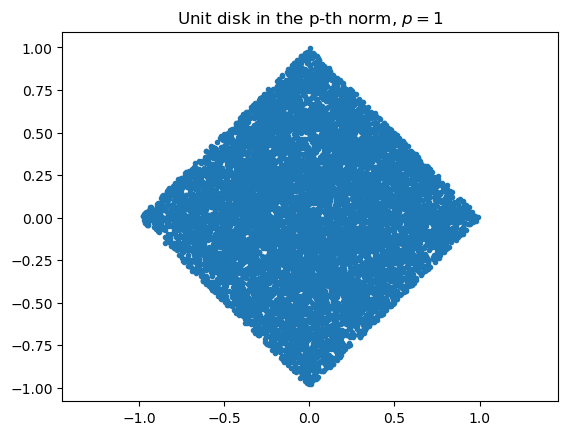

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
p = 1 # Which norm do we use
M = 40000 # Number of sampling points
b = []
for i in range(M):
    a = np.random.randn(2, 1)
    if np.linalg.norm(a[:, 0], p) <= 1:
        b.append(a[:, 0])
b = np.array(b)
plt.plot(b[:, 0], b[:, 1], '.')
plt.axis('equal')
plt.title('Unit disk in the p-th norm, $p={0:}$'.format(p))

## Why $L_1$-norm can be important?

$L_1$ norm, as it was discovered quite recently, plays an important role in **compressed sensing**. 

The simplest formulation of the considered problem is as follows:

- You have some observations $f$ 
- You have a linear model $Ax = f$, where $A$ is an $n \times m$ matrix, $A$ is **known**
- The number of equations, $n$, is less than the number of unknowns, $m$

The question: can we find the solution?

The solution is obviously non-unique, so a natural approach is to find the solution that is minimal in the certain sense:

\begin{align*}
& \Vert x \Vert \rightarrow \min_x \\
\mbox{subject to } & Ax = f
\end{align*}

- Typical choice of $\Vert x \Vert = \Vert x \Vert_2$ leads to the **linear least squares problem** (and has been used for ages).  

- The choice $\Vert x \Vert = \Vert x \Vert_1$ leads to the [**compressed sensing**](https://en.wikipedia.org/wiki/Compressed_sensing)
- It typically yields the **sparsest solution**  

## What is a stable algorithm?

And we finalize the lecture by the concept of **stability**.

- Let $x$ be an object (for example, a vector) 
- Let $f(x)$ be the function (functional) you want to evaluate 

You also have a **numerical algorithm** ``alg(x)`` that actually computes **approximation** to $f(x)$.  

The algorithm is called **forward stable**, if 

$$\Vert \text{alg}(x) - f(x) \Vert  \leq \varepsilon $$  

The algorithm is called **backward stable**, if for any $x$ there is a close vector $x + \delta x$ such that

$$\text{alg}(x) = f(x + \delta x)$$

and $\Vert \delta x \Vert$ is small.

## Classical example
A classical example is the **solution of linear systems of equations** using Gaussian elimination which is similar to LU factorization (more details later)

We consider the **Hilbert matrix** with the elements

$$A = \{a_{ij}\}, \quad a_{ij} = \frac{1}{i + j + 1}, \quad i,j = 0, \ldots, n-1.$$

And consider a linear system

$$Ax = f.$$

We will look into matrices in more details in the next lecture, and for linear systems in the upcoming weeks

1.3614802098870779e-07


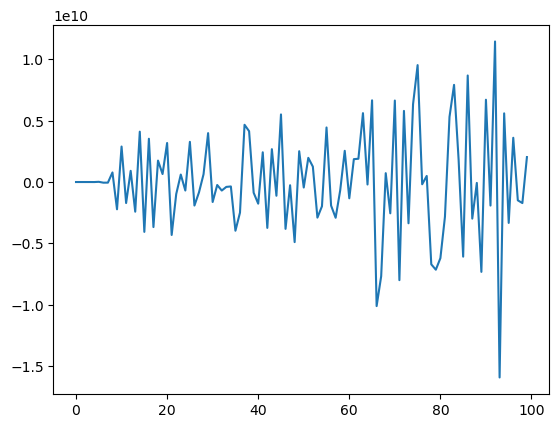

In [23]:
import numpy as np
n = 100
a = [[1.0/(i + j + 1) for i in range(n)] for j in range(n)] # Hilbert matrix
A = np.array(a)
rhs =  np.ones(n)#np.random.randn(n)
sol = np.linalg.solve(A, rhs)
print(np.linalg.norm(A @ sol - rhs)/np.linalg.norm(rhs))
plt.plot(sol)

In [34]:
rhs = jnp.ones(n)
sol = jnp.linalg.solve(A, rhs)
print(jnp.linalg.norm(A @ sol - rhs)/jnp.linalg.norm(rhs))
#plt.plot(sol)

0.0018351191


## More examples of instability

How to compute the following functions in numerically stable manner?

- $\log(1 - \tanh^2(x))$
- $\text{SoftMax}(x)_j = \dfrac{e^{x_j}}{\sum\limits_{i=1}^n e^{x_i}}$  

In [27]:
u = 30
eps = 1e-6
print("Original function:", np.log(1 - np.tanh(u)**2))
eps_add = np.log(1 - np.tanh(u)**2 + eps)
print("Attempt to improve stability by adding a small constant:", eps_add)
print("Use more numerically stable form:", np.log(4) - 2 * np.log(np.exp(-u) + np.exp(u)))

Original function: -inf
Attempt to improve stability by adding a small constant: -13.815510557964274
Use more numerically stable form: -58.61370563888011


/var/folders/x_/_k8z8m6s2qxc_j4gwz6fpvmm0000gp/T/ipykernel_68783/3185928406.py:3: RuntimeWarning: divide by zero encountered in log
  print("Original function:", np.log(1 - np.tanh(u)**2))


In [30]:
n = 5
x = jax.random.normal(jax.random.PRNGKey(0), (n, ))
x = x.at[0].set(1000)
print(jnp.exp(x) / jnp.sum(jnp.exp(x)))
print(jnp.exp(x - jnp.max(x)) / jnp.sum(jnp.exp(x - jnp.max(x))))

[nan  0.  0.  0.  0.]
[1. 0. 0. 0. 0.]


## Take home message
- Floating point  (double, single, number of bytes), rounding error
- Norms are measures of smallness, used to compute the accuracy
- $1$, $p$ and Euclidean norms 
- $L_1$ is used in compressed sensing as a surrogate for sparsity (later lectures) 
- Forward/backward error (and stability of algorithms)  (later lectures)

## Next lecture

- Matrix norms: what is the difference between matrix and vector norms
- Unitary matrices, including elementary unitary matrices.

# Lecture 2. Matrix norms and unitary matrices

## Recap of the previous lecture

- Floating point  (double, single, half precisions, number of bytes), rounding error
- Vector norms are measures of smallness, used to compute the distance and accuracy
- Forward/backward error (and stability of algorithms)

## Notations

We use notation 

$$A= \begin{bmatrix} a_{11} & \dots & a_{1m} \\ \vdots & \ddots & \vdots \\ a_{n1} & \dots & a_{nm}  \end{bmatrix} \equiv \{a_{ij}\}_{i,j=1}^{n,m}\in \mathbb{C}^{n\times m}.$$

$A^*\stackrel{\mathrm{def}}{=}\overline{A^\top}$.

## Matrices and norms

- Recall vector norms that allow to evaluate distance between two vectors or how large are elements of a vector.

- How to generalize this concept to matrices?

- A trivial answer is that there is no big difference between matrices and vectors, and here comes the simplest matrix norm –– **Frobenius** norm:

$$ \Vert A \Vert_F \stackrel{\mathrm{def}}{=} \Big(\sum_{i=1}^n \sum_{j=1}^m |a_{ij}|^2\Big)^{1/2} $$

## Matrix norms
$\Vert \cdot \Vert$ is called a **matrix norm** if it is a vector norm on the vector space of $n \times m$ matrices:
1. $\|A\| \geq 0$ and if $\|A\| = 0$ then $A = O$
3. $\|\alpha A\| = |\alpha| \|A\|$
4. $\|A+B\| \leq \|A\| + \|B\|$ (triangle inequality)

Additionally some norms can satisfy the *submultiplicative property*

* <span style="color:red"> $\Vert A B \Vert \leq \Vert A \Vert \Vert B \Vert$ </span>

- These norms are called **submultiplicative norms**.

- The submultiplicative property is needed in many places, for example in the estimates for the error of solution of linear systems (we will cover this topic later). 

- Example of a non-submultiplicative norm is Chebyshev norm 

$$ \|A\|_C = \displaystyle{\max_{i,j}}\, |a_{ij}| $$

## Operator norms

- The most important class of the matrix norms is the class of **operator norms**. They are defined as

$$ \Vert A \Vert_{*,**} = \sup_{x \ne 0} \frac{\Vert A x \Vert_*}{\Vert x \Vert_{**}}, $$

where $\Vert \cdot \Vert_*$ and $\| \cdot \|_{**}$ are **vector norms**.

- It is easy to check that operator norms are submultiplicative if $\|\cdot\|_* = \|\cdot\|_{**}$. Otherwise, it can be non-submultiplicative, think about example.

- **Frobenius norm** is a matrix norm, but not an operator norm, i.e. you can not find $\Vert \cdot \Vert_*$ and $\| \cdot \|_{**}$ that induce it. 
- This is a nontrivial fact and the general criterion for matrix norm to be an operator norm can be found in [Theorem 6 and Corollary 4](http://www.sciencedirect.com/science/article/pii/S0024379515004346).
For $\Vert \cdot \Vert_* = \| \cdot \|_{**}$ let us check on the blackboard!

## Matrix $p$-norms

Important case of operator norms are matrix $p$-norms, which are defined for $\|\cdot\|_* = \|\cdot\|_{**} = \|\cdot\|_p$. <br>

Among all $p$-norms three norms are the most common ones:  

- $p = 1, \quad \Vert A \Vert_{1} = \displaystyle{\max_j \sum_{i=1}^n} |a_{ij}|$.

- $p = 2, \quad$ spectral norm, denoted by $\Vert A \Vert_2$.

- $p = \infty, \quad \Vert A \Vert_{\infty} = \displaystyle{\max_i \sum_{j=1}^m} |a_{ij}|$.

Let us check it for $p=\infty$ on a blackboard.

## Spectral norm

- Spectral norm, $\Vert A \Vert_2$ is one of the most used matrix norms (along with the Frobenius norm). 
- It can not be computed directly from the entries using a simple formula, like the Frobenius norm, however, there are efficient algorithms to compute it.  
- It is directly related to the **singular value decomposition** (SVD) of the matrix. It holds

$$ \Vert A \Vert_2 = \sigma_1(A) = \sqrt{\lambda_{\max}(A^*A)} $$

where $\sigma_1(A)$ is the largest singular value of the matrix $A$ and $^*$ is a *conjugate transpose* of the matrix. 

- We will soon learn all about the SVD. Meanwhile, we can already compute the norm in Python.

In [ ]:
import numpy as np
n = 100
m = 2000
a = np.random.randn(n, m) #Random n x m matrix
s1 = np.linalg.norm(a, 2) #Spectral
s2 = np.linalg.norm(a, 'fro') #Frobenius
s3 = np.linalg.norm(a, 1) #1-norm
s4 = np.linalg.norm(a, np.inf) 
print('Spectral: {0:} \nFrobenius: {1:} \n1-norm: {2:} \ninfinity: {3:}'.format(s1, s2, s3, s4))

Spectral: 54.23724766209146 
Frobenius: 447.08449637895757 
1-norm: 102.09472515184673 
infinity: 1690.7456169067727


## Examples

Several examples of optimization problems where matrix norms arise:
* <span style="color:red"> $\displaystyle{\min_{\mathrm{rank}(A_r)=r}}\| A - A_r\|$ </span> –– finding best rank-r approximation. SVD helps to solve this problem for $\|\cdot\|_2$ and $\|\cdot\|_F$.


* $\displaystyle{\min_B}\| P_\Omega \odot(A - B)\| + \mathrm{rank}(B)$ –– matrix completion. 

$$ (P_\Omega)_{ij} = \begin{cases} 1 & i,j\in\Omega \\ 0 & \text{otherwise}, \end{cases} $$

where $\odot$ denotes Hadamard product (elementwise)


* $\displaystyle{\min_{B,C\geq 0}} \|A - BC\|_F$ –– nonnegative matrix factorization. Symbol $B\geq0$ here means that all elements of $B$ are nonnegative.

## Scalar product
While norm is a measure of distance, the **scalar product** takes angle into account.  

It is defined as

* **For vectors:**
$$ (x, y) =  x^* y = \sum_{i=1}^n \overline{x}_i y_i, $$
where $\overline{x}$ denotes the *complex conjugate* of $x$. The Euclidean norm is then

$$ \Vert x \Vert_2 = \sqrt{(x, x)}, $$

or it is said the norm is **induced** by the scalar product.  


* **For matrices** (Frobenius scalar product):

$$ (A, B)_F = \displaystyle{\sum_{i=1}^{n}\sum_{j=1}^{m}} \overline{a}_{ij} b_{ij} \equiv \mathrm{trace}(A^* B), $$

where $\mathrm{trace}(A)$ denotes the sum of diagonal elements of $A$. One can check that $\|A\|_F = \sqrt{(A, A)_F}$.

**Remark**. The angle between two vectors is defined as

$$ \cos \phi = \frac{(x, y)}{\Vert x \Vert_2 \Vert y \Vert_2}. $$

Similar expression holds for matrices.

- An important property of the scalar product is the **Cauchy-Schwarz-Bunyakovski inequality**:

$$|(x, y)| \leq \Vert x \Vert_2 \Vert y \Vert_2,$$

and thus the angle between two vectors is defined properly.

## Matrices preserving the norm

- For stability it is really important that the error does not grow after we apply some transformations. 

- Suppose you are given $\widehat{x}$ –– the approximation of $x$ such that,  

$$ \frac{\Vert x - \widehat{x} \Vert}{\Vert x \Vert} \leq \varepsilon. $$

- Let us calculate a linear transformation of $x$ and $\widehat{x}$:  

$$ y = U x, \quad \widehat{y} = U \widehat{x}. $$

- When building new algorithms, we want to use transformations that do not increase (or even preserve) the error:

$$ \frac{\Vert y - \widehat{y} \Vert}{\Vert y \Vert } = \frac{\Vert U ( x - \widehat{x}) \Vert}{\Vert U  x\Vert}  \leq \varepsilon. $$

- The question is for which kind of matrices the norm of the vector **will not change**, so that

$$ \frac{\Vert U ( x - \widehat{x}) \Vert}{\Vert U  x\Vert} = \frac{ \|x - \widehat{x}\|}{\|x\|}. $$

- For the euclidean norm $\|\cdot\|_2$ the answer is **unitary** (or orthogonal in the real case) matrices.

## Unitary (orthogonal) matrices

- Let $U$ be complex $n \times n$ matrix, and $\Vert U z \Vert_2 = \Vert z \Vert_2$ for all $z$. 

- This can happen **if and only if** (can be abbreviated as **iff**)

$$ U^* U = I_n, $$

where $I_n$ is an identity matrix $n\times n$.

- Complex $n\times n$ square matrix is called **unitary** if

$$ U^*U = UU^* = I_n, $$

which means that columns and rows of unitary matrices both form orthonormal basis in $\mathbb{C}^{n}$.

- For rectangular matrices of size $m\times n$ ($n\not= m$) only one of the equalities can hold

    - $ U^*U = I_n$ –– left unitary for $m>n$
    - $ UU^* = I_m$  –– right unitary for $m<n$

- In the case of real matrices $U^* = U^T$ and matrices such that

$$ U^TU = UU^T = I $$

are called **orthogonal**.

## Unitary matrices

Important property: **a product of two unitary matrices is a unitary matrix:**  

$$(UV)^* UV = V^* (U^* U) V = V^* V = I,$$

- Later we will show that there are types of matrices (**Householder reflections** and **Givens rotations**) composition of which is able to produce arbitrary unitary matrix
- This idea is a core of some algorithms, e.g. QR decomposition

## Unitary invariance of $\|\cdot\|_2$ and $\|\cdot\|_F$ norms

- For vector 2-norm we have already seen that $\Vert U z \Vert_2 = \Vert z \Vert_2$ for any unitary $U$.

- One can show that unitary matrices also do not change matrix norms $\|\cdot\|_2$ and $\|\cdot\|_F$, i.e. for any square $A$ and unitary $U$,$V$: 

$$ \| UAV\|_2 = \| A \|_2 \qquad \| UAV\|_F = \| A \|_F.$$

- For $\|\cdot\|_2$ it follows from the definition of an operator norm and the fact that vector 2-norm is unitary invariant.

- For $\|\cdot\|_F$ it follows from $\|A\|_F^2 = \mathrm{trace}(A^*A)$ and the fact that $\mathrm{trace}(BC) = \mathrm{trace}(CB)$.

## Examples of unitary matrices
- There are two important classes of unitary matrices, using composition of which we can construct any unitary matrix:

    1. Householder matrices
    2. Givens (Jacobi) matrices

- Other important examples are
    * **Permutation matrix** $P$ whose rows (columns) are permutation of rows (columns) of the identity matrix.
    * **Fourier matrix** $F_n = \frac{1}{\sqrt{n}} \left\{ e^{-i\frac{2\pi kl}{n}}\right\}_{k,l=0}^{n-1}$

## Householder matrices

- Householder matrix is the matrix of the form 

$$H \equiv H(v) = I - 2 vv^*,$$

where $v$ is an $n \times 1$ column and $v^* v = 1$. 
- Can you show that $H$ is unitary and Hermitian ($H^* = H$)?  
- It is also a reflection:

$$ Hx = x - 2(v^* x) v$$

<img src="misc/householder.jpeg" width=500>  

## Important property of Householder reflection

- A nice property of Householder transformation is that it can zero all elements of a vector except for the first one:

$$ H \begin{bmatrix} \times \\ \times \\ \times \\ \times  \end{bmatrix} =  \begin{bmatrix} \times \\ 0 \\ 0 \\ 0  \end{bmatrix}. $$

*Proof (for real case).* Let $e_1 = (1,0,\dots, 0)^T$, then we want to find $v$ such that

$$ H x = x - 2(v^* x) v = \alpha e_1, $$

where $\alpha$ is an unknown constant. Since $\|\cdot\|_2$ is unitary invariant we get

$$\|x\|_2 = \|Hx\|_2 = \|\alpha e_1\|_2 = |\alpha|.$$

and $$\alpha = \pm \|x\|_2$$

Also, we can express $v$ from $x - 2(v^* x) v = \alpha e_1$:

$$v = \dfrac{x-\alpha e_1}{2 v^* x}$$

Multiplying the latter expression by $x^*$ we get

$$x^* x - 2 (v^* x) x^* v = \alpha x_1; $$

or 

$$ \|x\|_2^2 - 2 (v^* x)^2 = \alpha x_1. $$

Therefore,

$$ (v^* x)^2 = \frac{\|x\|_2^2 - \alpha x_1}{2}. $$

So, $v$ exists and equals

$$ v = \dfrac{x \mp \|x\|_2 e_1}{2v^* x} = \dfrac{x \mp \|x\|_2 e_1}{\pm\sqrt{2(\|x\|_2^2 \mp \|x\|_2 x_1)}}. $$

## Householder algorithm for QR decomposition

Using the obtained property we can make arbitrary matrix $A$ lower triangular:

$$
H_2 H_1 A = \begin{bmatrix} \times & \times & \times & \times \\ 0 & \times & \times & \times  \\  0 & 0 & \boldsymbol{\times} & \times\\ 0 &0 & \boldsymbol{\times} & \times  \\ 0 &0 & \boldsymbol{\times} & \times \end{bmatrix} $$

then finding $H_3=\begin{bmatrix}I_2 & \\ & {\widetilde H}_3 \end{bmatrix}$ such that

$$ {\widetilde H}_3 \begin{bmatrix} \boldsymbol{\times}\\ \boldsymbol{\times} \\ \boldsymbol{\times}  \end{bmatrix} = \begin{bmatrix} \times \\ 0 \\ 0  \end{bmatrix}. $$

we get

$$ H_3 H_2 H_1 A =  \begin{bmatrix} \times & \times & \times & \times \\  0 & \times & \times & \times  \\  0 & 0 & {\times} & \times\\  0 &0 & 0 & \times  \\  0 &0 & 0 & \times  \end{bmatrix} $$

Finding $H_4$ by analogy we arrive at upper-triangular matrix.

Since product and inverse of unitary matrices is a unitary matrix we get:

**Corollary:** (QR decomposition) Every $A\in \mathbb{C}^{n\times m}$ can be represented as

$$ A = QR, $$

where $Q$ is unitary and $R$ is upper triangular. 

See [poster](../decompositions.pdf), what are the sizes of $Q$ and $R$ for $n>m$ and $n<m$.

## Givens (Jacobi) matrix

- A Givens matrix is a matrix  

$$ G = \begin{bmatrix} \cos \alpha & -\sin \alpha \\ \sin \alpha & \cos \alpha \end{bmatrix},$$

which is a rotation. 

- For a general case, we select two $(i, j)$ planes and rotate vector $x$  

$$ x' = G x, $$

only in the $i$-th and $j$-th positions:

$$ x'_i =  x_i\cos \alpha - x_j\sin \alpha , \quad x'_j = x_i \sin \alpha  +  x_j\cos\alpha, $$

with all other $x_i$ remain unchanged.
- Therefore, we can make elements in the $j$-th  position zero by choosing $\alpha$ such that

$$ \cos \alpha = \frac{x_i}{\sqrt{x_i^2 + x_j^2}}, \quad \sin \alpha = -\frac{x_j}{\sqrt{x_i^2 + x_j^2}} $$

(-1.0, 1.0)

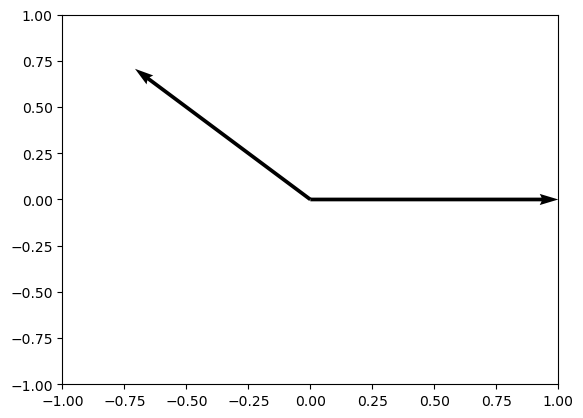

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

alpha = -3*np.pi / 4
G = np.array([
    [np.cos(alpha), -np.sin(alpha)],
    [np.sin(alpha), np.cos(alpha)]
])
x = np.array([-1./np.sqrt(2), 1./np.sqrt(2)])
y = G @ x

plt.quiver([0, 0], [0, 0], [x[0], y[0]], [x[1], y[1]], angles='xy', scale_units='xy', scale=1)
plt.xlim(-1., 1.)
plt.ylim(-1., 1.)

## QR via Givens rotations

Similarly we can make matrix upper-triangular using Givens rotations:

$$\begin{bmatrix} \times & \times & \times \\ \bf{*} & \times & \times \\ \bf{*} & \times & \times \end{bmatrix} \to \begin{bmatrix} * & \times & \times \\ * & \times & \times \\ 0 & \times & \times \end{bmatrix} \to \begin{bmatrix} \times & \times & \times \\ 0 & * & \times \\ 0 & * & \times \end{bmatrix} \to \begin{bmatrix} \times & \times & \times \\ 0 & \times & \times \\ 0 & 0 & \times \end{bmatrix} $$

## Givens vs. Householder transformations

- Householder reflections are useful for dense matrices (complexity is $\approx$ twice smaller than for Jacobi) and we need to zero large number of elements.
- Givens rotations are more suitable for sparse matrice or parallel machines as they act locally on elements.

## Singular Value Decomposition

SVD will be considered later in more details.

**Theorem.** Any matrix $A\in \mathbb{C}^{n\times m}$ can be written as a product of three matrices:  

$$ A = U \Sigma V^*, $$

where 
- $U$ is an $n \times n$ unitary matrix
- $V$ is an $m \times m$ unitary matrix
- $\Sigma$ is a diagonal matrix with non-negative elements $\sigma_1 \geq  \ldots, \geq \sigma_{\min (m,n)}$ on the diagonal.

Moreover, if $\text{rank}(A) = r$, then $\sigma_{r+1} = \dots = \sigma_{\min (m,n)} = 0$.

See [poster](../decompositions.pdf) for the visualization.

<img src="misc/svd_picture.png">

- **Important note:** if one truncates (replace by $0$) all singular values except for $r$ first, then the resulting matrix yields best rank-$r$ approximation both in $\|\cdot\|_2$ and $\|\cdot\|_F$. 
- This is called Eckart-Young theorem and will be proved later in our course.

## Muon optimizer: matrix-aware optimization algorithm

Optimization problem, $f(W) \rightarrow \min$, where $W$ is a matrix.

Gradient descent: $f(W+dW) \approx f(W) + \langle f'(W), dW \rangle \rightarrow \min, \quad \Vert W \Vert \leq 1$

If we replace **Frobenius norm** with **spectral norm**, we get Muon optimizer.

Implementation is non-trivial!

## Summary 

- Most important matrix norms: Frobenius and spectral

- Unitary matrices preserve these norms

- There are two "basic" classes of unitary matrices: Householder and Givens matrices

## Questions?

# Lecture 3: Matvecs and matmuls, memory hierarchy, Strassen algorithm

## Recap of the previous lectures

- Floating point arithmetics and related issues
- Stable algorithms: backward and forward stability
- Most important matrix norms: spectral and Frobenius
- Unitary matrices preserve these norms
- There are two "basic" classes of unitary matrices: Householder and Givens matrices

## Examples of peak performance

**Flops** –– floating point operations per second.

Giga = $2^{30} \approx 10^9$,  
Tera = $2^{40} \approx 10^{12}$,      
Peta = $2^{50} \approx 10^{15}$,       
Exa = $2^{60} \approx 10^{18}$ 

What is the **peak perfomance** of:

1. Modern CPU
2. Modern GPU
3. Largest supercomputer of the world? 

### Clock frequency of CPU vs. performance in flops

FLOPS = sockets * (cores per socket) * (number of clock cycles per second) * (number of floating point operations per cycle).

- Typically sockets = 1
- Number of cores is typically 2 or 4
- Number of ticks per second is familiar clock frequency
- Number of floating point operations per tick depends on the particular CPU


1. Modern CPU (Intel Core i7)   –– 400 Gflops
2. Modern GPU [Nvidia DGX H100](https://www.nvidia.com/en-us/data-center/h100/) -- depends on the precision!
3. Largest supercomputer in the world –– 1.102 Exaflop/s –– peak performanse 



## Matrix-by-vector multiplication (matvec)

Multiplication of an $n\times n$ matrix $A$ by a vector $x$ of size $n\times 1$ ($y=Ax$):

$$
y_{i} = \sum_{j=1}^n a_{ij} x_j
$$

requires $n^2$ mutliplications and $n(n-1)$ additions. Thus, the overall complexity is $2n^2 - n =$ <font color='red'> $\mathcal{O}(n^2)$ </font>

## How bad is $\mathcal{O}(n^2)$?

- Let $A$ be the matrix of pairwise gravitational interaction between planets in a galaxy.

- The number of planets in an average galaxy is $10^{11}$, so the size of this matrix is $10^{11} \times 10^{11}$.

- To model evolution in time we have to multiply this matrix by vector at each time step.

- Top supercomputers do around $10^{16}$ floating point operations per second (flops), so the time required to multiply the matrix $A$ by a vector is approximately

\begin{align*}
\frac{(10^{11})^2 \text{ operations}}{10^{16} \text{ flops}} = 10^6 \text{ sec} \approx 11.5 \text{ days} 
\end{align*}

for one time step. If we could multiply it with $\mathcal{O}(n)$ complexity, we would get

\begin{align*}
\frac{10^{11} \text{ operations}}{10^{16} \text{ flops}} = 10^{-5} \text{ sec}.
\end{align*}

Here is the YouTube video that illustrates collision of two galaxisies which was modelled by $\mathcal{O}(n \log n)$ algorithm:

In [2]:
from IPython.display import YouTubeVideo
YouTubeVideo("7HF5Oy8IMoM")

## Can we beat $\mathcal{O}(n^2)$?

- Generally speaking **NO**. 
- The point is that we have $\mathcal{O}(n^2)$ input data, so there is no way to be faster for a general matrix.
- Fortunately, we can be faster <font color='red'>for certain types of matrices</font>.
Here are some examples:
    * The simplest example may be a matrix of all ones, which can be easily multiplied with only $n-1$ additions. This matrix is of rank one. More generally we can multiply fast by <font color='red'>low-rank </font> matrices (or by matrices that have low-rank blocks)
    * <font color='red'>Sparse</font> matrices (contain $\mathcal{O}(n)$ nonzero elements)
    * <font color='red'>Structured</font> matrices:
      * Fourier
      * Circulant
      * Toeplitz 
      * Hankel

## Matrix-by-matrix product

Consider composition of two linear operators:

1. $y = Bx$
2. $z = Ay$

Then, $z = Ay =  A B x = C x$, where $C$ is the **matrix-by-matrix product**.

## Matrix-by-matrix product (MM): classics

**Definition**. A product of an $n \times k$ matrix $A$ and a $k \times m$ matrix $B$ is a $n \times m$ matrix $C$ with the elements  
$$
   c_{ij} = \sum_{s=1}^k a_{is} b_{sj}, \quad i = 1, \ldots, n, \quad j = 1, \ldots, m 
$$

For $m=k=n$ complexity of a na&iuml;ve algorithm is $2n^3 - n^2 =$ <font color='red'>$\mathcal{O}(n^3)$</font>.   

## Discussion of MM

- Matrix-by-matrix product is the **core** for almost all efficient algorithms in numerical linear algebra.  

- Basically, all the dense NLA algorithms are reduced to a sequence of matrix-by-matrix products.

- Efficient implementation of MM reduces the complexity of numerical algorithms by the same factor.  

- However, implementing MM is not easy at all!

## Efficient implementation for MM
**Q1**: Is it easy to multiply a matrix by a matrix in the most efficient way?

## Answer: no, it is not easy

If you want it as fast as possible, using the computers that are at hand.

## Demo
Let us do a short demo and compare a `np.dot()` procedure which in my case uses MKL with a hand-written matrix-by-matrix routine in Python and also its numba version.

In [5]:
import numpy as np
def matmul(a, b):
    n = a.shape[0]
    k = a.shape[1]
    m = b.shape[1]  
    c = np.zeros((n, m))
    for i in range(n):
        for j in range(m):
            for s in range(k):
                c[i, j] += a[i, s] * b[s, j]
                
    return c

In [3]:
import numpy as np
from numba import jit # Just-in-time compiler for Python, see http://numba.pydata.org 

@jit(nopython=True)
def numba_matmul(a, b):
    n = a.shape[0]
    k = a.shape[1]
    m = b.shape[1]
    c = np.zeros((n, m))
    for i in range(n):
        for j in range(m):
            for s in range(k):
                c[i, j] += a[i, s] * b[s, j]
    return c

Then we just compare computational times.

Guess the answer.

In [7]:
import numpy as np
#from jax.config import config
#config.update("jax_enable_x64", True)

n = 100
a = np.random.randn(n, n)
b = np.random.randn(n, n)

a_jax = np.array(a)
b_jax = np.array(b)

%timeit matmul(a, b)
%timeit numba_matmul(a, b)
%timeit a @ b

251 ms ± 3.52 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
541 μs ± 4.84 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
10.4 μs ± 15.1 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


Is this answer correct for any dimensions of matrices?

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

dim_range = [10*i for i in range(1, 11)]
time_range_matmul = []
time_range_numba_matmul = []
time_range_np = []
for n in dim_range:
    print("Dimension = {}".format(n))
    a = np.random.randn(n, n)
    b = np.random.randn(n, n)

    t = %timeit -o -q matmul(a, b)
    time_range_matmul.append(t.best)
    t = %timeit -o -q numba_matmul(a, b)
    time_range_numba_matmul.append(t.best)
    t = %timeit -o -q np.dot(a, b)
    time_range_np.append(t.best)

Dimension = 10
Dimension = 20
Dimension = 30
Dimension = 40
Dimension = 50
Dimension = 60
Dimension = 70
Dimension = 80
Dimension = 90
Dimension = 100


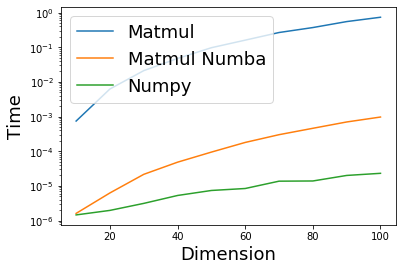

In [11]:
plt.plot(dim_range, time_range_matmul, label="Matmul")
plt.plot(dim_range, time_range_numba_matmul, label="Matmul Numba")
plt.plot(dim_range, time_range_np, label="Numpy")
plt.legend(fontsize=18)
plt.xlabel("Dimension", fontsize=18)
plt.ylabel("Time", fontsize=18)
plt.yscale("log")

## Why is na&iuml;ve implementation slow?
It is slow due to two issues:

- It does not use the benefits of fast memory (cache) and in general memory architecture
- It does not use available parallelization ability (especially important for GPU) 

## Memory architecture
<img width=80% src="misc/Memory-Hierarchy.jpg">

- Fast memory is small
- Bigger memory is slow

## Typical Memory Hierarchy Specifications

 | Memory Type | Size | Access Time | Notes |
 |------------|------|-------------|--------|
 | CPU Registers | Few KB | <1 ns | Fastest, directly accessed by CPU |
 | L1 Cache | 32-64 KB | 1-4 ns | Split into instruction and data cache |
 | L2 Cache | 256 KB - 1 MB | 4-10 ns | Unified cache |
 | L3 Cache | 2-32 MB | 10-20 ns | Shared between CPU cores |
 | Main Memory (RAM) | 8-32 GB | 100 ns | Primary system memory |
 | SSD | 256 GB - 2 TB | 10-100 μs | Fast secondary storage |
 | Hard Drive | 1-10 TB | 5-10 ms | Slowest but largest storage |

 Key observations:
 - Access time increases ~10x at each level
 - Size increases ~10-100x at each level
 - Effective use of faster memory levels is crucial for performance


## Cache Lines and Cache Coherence
 
 - Cache memory is organized into **cache lines** - fixed-size blocks (typically 64 bytes)
 - When CPU needs data, it loads entire cache line containing that data
 - This is efficient when accessing sequential memory (spatial locality)
 
 **Cache coherence** ensures that:
 - Multiple CPU cores see consistent view of memory
 - When one core modifies data, other cores are notified
 - Prevents race conditions and data inconsistency
 
 Why it matters for matrix operations:
 - Sequential access to matrix rows/columns affects cache line utilization
 - Poor cache line usage = more cache misses = slower performance
 - Multi-threaded code needs coherent caches for correctness


# GPU Memory Architecture
 
 Modern GPUs have a different memory hierarchy compared to CPUs:
 
 | Memory Type | Size | Access Time | Notes |
 |------------|------|-------------|--------|
 | Registers | ~4 MB per SM | ~1 clock | Fastest, per thread/block |
 | Shared Memory/L1 Cache | 64-256 KB per SM | ~20-30 clocks | Shared within thread block |
 | L2 Cache | 512KB - 60MB | ~200 clocks | Shared across GPU |
 | Global Memory (VRAM) | 16-80 GB | ~400-600 clocks | Main GPU memory |
 | System RAM | 8-128 GB | >1000 clocks | CPU memory, accessed via PCIe |
 
 Key differences from CPU:
 - Much more parallel access (thousands of threads)
 - Larger register file but smaller caches
 - Higher memory bandwidth but higher latency
 - Coalesced memory access critical for performance
 
 Memory access patterns:
 - Coalesced: threads in a warp access consecutive memory = fast
 - Strided/random: threads access scattered memory = slow
 - Shared memory bank conflicts can limit bandwidth
 
 Best practices:
 - Use shared memory for frequently accessed data
 - Ensure coalesced global memory access
 - Minimize data transfer between CPU and GPU
 
 Note: The latest NVIDIA H100 GPU can have up to 80GB of HBM3 VRAM



## Making algorithms more computationally intensive 

<font color='red'>**Implementation in NLA**</font>: use block version of algorithms. <br>

This approach is a core of **[BLAS (Basic Linear Algebra Subroutines)](http://www.netlib.org/blas/)**, written in Fortran many years ago, and still rules the computational world.

Split the matrix into blocks! For illustration consider splitting in $2 \times 2$ block matrix:

$$
   A = \begin{bmatrix}
         A_{11} & A_{12} \\
         A_{21} & A_{22}
        \end{bmatrix}, \quad B = \begin{bmatrix}
         B_{11} & B_{12} \\
         B_{21} & B_{22}
        \end{bmatrix}$$

Then,  

$$AB = \begin{bmatrix}A_{11} B_{11} + A_{12} B_{21} & A_{11} B_{12} + A_{12} B_{22} \\
            A_{21} B_{11} + A_{22} B_{21} & A_{21} B_{12} + A_{22} B_{22}\end{bmatrix}.$$  

If $A_{11}, B_{11}$ and their product fit into the cache memory (which is 20 Mb (L3) for the [recent Intel Chip](https://en.wikipedia.org/wiki/List_of_Intel_processors#Desktop_(codenamed_%22Comet_Lake%22))), then we load them only once into the memory.  

## BLAS
BLAS has three levels:
1. BLAS-1, operations like $c = a + b$
2. BLAS-2, operations like matrix-by-vector product
3. BLAS-3, matrix-by-matrix product

What is the principal differences between them?

The main difference is the number of operations vs. the number of input data!

1. BLAS-1: $\mathcal{O}(n)$ data, $\mathcal{O}(n)$ operations
2. BLAS-2: $\mathcal{O}(n^2)$ data, $\mathcal{O}(n^2)$ operations
3. BLAS-3: $\mathcal{O}(n^2)$ data, $\mathcal{O}(n^3)$ operations

## Why BLAS is so important and actual?

1. The state-of-the-art implementation of the basic linear algebra operations
2. Provides standard names for operations in any new implementations (e.g. [ATLAS](https://www.netlib.org/atlas/), [OpenBLAS](https://www.openblas.net/), [MKL](https://software.intel.com/en-us/mkl)). You can call matrix-by-matrix multiplication function (GEMM), link your code with any BLAS implementation and it will work correctly
3. Formulate new algorithms in terms of BLAS operations
4. There are wrappers for the most popular languages

## Packages related to BLAS
 
1. [ATLAS](http://math-atlas.sourceforge.net) - Automatic Tuned Linear Algebra Software. It automatically adapts to a particular system architechture. 
2. [LAPACK](http://www.netlib.org/lapack/) - Linear Algebra Package. It provides high-level linear algebra operations (e.g. matrix factorizations), which are based on calls of BLAS subroutines.
3. [Intel MKL](https://software.intel.com/en-us/intel-mkl) - Math Kernel Library. It provides re-implementation of BLAS and LAPACK, optimized for Intel processors. Available in Anaconda Python distribution: 
 ```
 conda install mkl
 ```
 
4. OpenBLAS is an optimized BLAS library based on [GotoBLAS](https://en.wikipedia.org/wiki/GotoBLAS). 
 
5. PyTorch [supports](https://pytorch.org/docs/stable/torch.html#blas-and-lapack-operations) some calls from BLAS and LAPACK
6. For NVIDIA GPUs, [cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) provides a GPU-accelerated implementation of BLAS.
 
7. For AMD GPUs, [rocBLAS](https://rocmdocs.amd.com/en/latest/ROCm_Libraries/ROCm_Libraries.html#rocblas) is part of the ROCm platform and offers a BLAS implementation optimized for AMD hardware.
 
For comparison of OpenBLAS and Intel MKL, see this [review](https://software.intel.com/en-us/articles/performance-comparison-of-openblas-and-intel-math-kernel-library-in-r)
 


## Faster algorithms for matrix multiplication

Recall that matrix-matrix multiplication costs $\mathcal{O}(n^3)$ operations.
However, storage is $\mathcal{O}(n^2)$.

**Question:** is it possible to reduce number operations down to $\mathcal{O}(n^2)$?

**Answer**: a quest for $\mathcal{O}(n^2)$ matrix-by-matrix multiplication algorithm is not yet done.

* Strassen gives $\mathcal{O}(n^{2.807\dots})$ –– sometimes used in practice 

* [Current world record](http://arxiv.org/pdf/1401.7714v1.pdf) $\mathcal{O}(n^{2.37\dots})$ –– big constant, not practical, based on [Coppersmith-Winograd_algorithm](https://en.wikipedia.org/wiki/Coppersmith%E2%80%93Winograd_algorithm).
- It improved the previous record (Williams 2012) by $3\cdot 10^{-7}$
- The papers still study multiplication of $3 \times 3$ matrices and interpret it from different sides ([Heule, et. al. 2019](https://arxiv.org/pdf/1905.10192.pdf)) 

Consider Strassen in more details. 

## Na&iuml;ve multiplication

Let $A$ and $B$ be two $2\times 2$ matrices. Na&iuml;ve multiplication $C = AB$

$$
\begin{bmatrix} c_{11} & c_{12} \\ c_{21} & c_{22}  \end{bmatrix}  =
\begin{bmatrix} a_{11} & a_{12} \\ a_{21} & a_{22}  \end{bmatrix}
\begin{bmatrix} b_{11} & b_{12} \\ b_{21} & b_{22}  \end{bmatrix} =
\begin{bmatrix} 
a_{11}b_{11} + a_{12}b_{21} & a_{11}b_{21} + a_{12}b_{22} \\ 
a_{21}b_{11} + a_{22}b_{21} & a_{21}b_{21} + a_{22}b_{22} 
\end{bmatrix}
$$

contains $8$ multiplications and $4$ additions.

## Strassen algorithm

In the work [Gaussian elimination is not optimal](http://link.springer.com/article/10.1007%2FBF02165411?LI=true) (1969) Strassen found that one can calculate $C$ using 18 additions and only 7 multiplications:
$$
\begin{split}
c_{11} &= f_1 + f_4 - f_5 + f_7, \\
c_{12} &= f_3 + f_5, \\
c_{21} &= f_2 + f_4, \\
c_{22} &= f_1 - f_2 + f_3 + f_6,
\end{split}
$$
where
$$
\begin{split}
f_1 &= (a_{11} + a_{22}) (b_{11} + b_{22}), \\
f_2 &= (a_{21} + a_{22}) b_{11}, \\
f_3 &= a_{11} (b_{12} - b_{22}), \\
f_4 &= a_{22} (b_{21} - b_{11}), \\
f_5 &= (a_{11} + a_{12}) b_{22}, \\
f_6 &= (a_{21} - a_{11}) (b_{11} + b_{12}), \\
f_7 &= (a_{12} - a_{22}) (b_{21} + b_{22}).
\end{split}
$$

Fortunately, these formulas hold even if $a_{ij}$ and $b_{ij}$, $i,j=1,2$ are block matrices.

Thus, Strassen algorithm looks as follows. 
- First of all we <font color='red'>split</font> matrices $A$ and $B$ of sizes $n\times n$, $n=2^d$ <font color='red'> into 4 blocks</font> of size $\frac{n}{2}\times \frac{n}{2}$
- Then we <font color='red'>calculate multiplications</font> in the described formulas <font color='red'>recursively</font>

This leads us again to the **divide and conquer** idea.

## Example of Strassen algorithm
 
 Let's multiply two 2x2 matrices using Strassen's method:
 
$$A = \begin{bmatrix} 2 & 3 \\ 4 & 1 \end{bmatrix}, \quad B = \begin{bmatrix} 5 & 7 \\ 6 & 8 \end{bmatrix}$$
 
Calculate the 7 products $f_1$ through $f_7$:

$$\begin{align*}
f_1 &= (2 + 1)(5 + 8) = 3 \cdot 13 = 39 \\
f_2 &= (4 + 1)(5) = 5 \cdot 5 = 25 \\
f_3 &= (2)(7 - 8) = 2 \cdot (-1) = -2 \\
f_4 &= (1)(6 - 5) = 1 \cdot 1 = 1 \\
f_5 &= (2 + 3)(8) = 5 \cdot 8 = 40 \\
f_6 &= (4 - 2)(5 + 7) = 2 \cdot 12 = 24 \\
f_7 &= (3 - 1)(6 + 8) = 2 \cdot 14 = 28
\end{align*}$$
 
Now compute the elements of result matrix $C$:
 
$$\begin{align*}
c_{11} &= f_1 + f_4 - f_5 + f_7 = 39 + 1 - 40 + 28 = 28 \\
c_{12} &= f_3 + f_5 = -2 + 40 = 38 \\
c_{21} &= f_2 + f_4 = 25 + 1 = 26 \\
c_{22} &= f_1 - f_2 + f_3 + f_6 = 39 - 25 - 2 + 24 = 36
\end{align*}$$
 
Therefore:
 
$$C = \begin{bmatrix} 28 & 38 \\ 26 & 36 \end{bmatrix}$$
 
You can verify this equals the result of standard matrix multiplication!


## Complexity of the Strassen algorithm

#### Number of multiplications

Calculation of number of multiplications is a trivial task. Let us denote by $M(n)$ number of multiplications used to multiply 2 matrices of sizes $n\times n$ using the divide and conquer concept.
Then for na&iuml;ve algorithm we have number of multiplications

$$ M_\text{naive}(n) = 8 M_\text{naive}\left(\frac{n}{2} \right) = 8^2 M_\text{naive}\left(\frac{n}{4} \right)
= \dots = 8^{d-1} M(2) = 8^{d} M(1) = 8^{d} = 8^{\log_2 n} = n^{\log_2 8} = n^3 $$

So, even when using divide and coquer idea we can not be better than $n^3$.

Let us calculate number of multiplications for the Strassen algorithm:

$$ M_\text{strassen}(n) = 7 M_\text{strassen}\left(\frac{n}{2} \right) = 7^2 M_\text{strassen}\left(\frac{n}{4} \right)
= \dots = 7^{d-1} M(1) = 7^{d} = 7^{\log_2 n} = n^{\log_2 7} $$

#### Number of additions

There is no point to estimate number of addtitions $A(n)$ for naive algorithm, as we already got $n^3$ multiplications.  
For the Strassen algorithm we have:

$$ A_\text{strassen}(n) = 7 A_\text{strassen}\left( \frac{n}{2} \right) + 18 \left( \frac{n}{2} \right)^2 $$

since on the first level we have to add $\frac{n}{2}\times \frac{n}{2}$ matrices 18 times and then go deeper for each of the 7 multiplications. Thus,

<font size=2.0>

$$ \begin{split}
A_\text{strassen}(n) =& 7 A_\text{strassen}\left( \frac{n}{2} \right) + 18 \left( \frac{n}{2} \right)^2 = 7 \left(7 A_\text{strassen}\left( \frac{n}{4} \right) + 18 \left( \frac{n}{4} \right)^2 \right) + 18 \left( \frac{n}{2} \right)^2 =
7^2 A_\text{strassen}\left( \frac{n}{4} \right) + 7\cdot 18 \left( \frac{n}{4} \right)^2 +  18 \left( \frac{n}{2} \right)^2 = \\
=& \dots = 18 \sum_{k=1}^d 7^{k-1} \left( \frac{n}{2^k} \right)^2 = \frac{18}{4} n^2 \sum_{k=1}^d \left(\frac{7}{4} \right)^{k-1} = \frac{18}{4} n^2 \frac{\left(\frac{7}{4} \right)^d - 1}{\frac{7}{4} - 1} = 6 n^2 \left( \left(\frac{7}{4} \right)^d - 1\right) \leqslant 6 n^2 \left(\frac{7}{4} \right)^d = 6 n^{\log_2 7}
\end{split}
$$
</font>

(since $4^d = n^2$ and $7^d = n^{\log_2 7}$).


Asymptotic behavior of $A(n)$ could be also found from the [master theorem](https://en.wikipedia.org/wiki/Master_theorem).

#### Total complexity

Total complexity is $M_\text{strassen}(n) + A_\text{strassen}(n)=$ <font color='red'>$7 n^{\log_2 7}$</font>. Strassen algorithm becomes faster
when

\begin{align*}
2n^3 &> 7 n^{\log_2 7}, \\
n &> 667,
\end{align*}

so it is not a good idea to get to the bottom level of recursion.

# Accelerating MM by parallelization

Historically, parallel implementations of many optimized **BLAS** libraries rely on so-called **bulk synchronous programming model**:
* Static work allocation and data distribution
* Alternating parallel and communication regions to satisfy data dependencies:
    * Parallel execution
    * Data communications
    * Parallel execution
    * Data communications
    * ...

# Task-based programming model

* Another parallel programming paradigm, which requires total reimplementation of all known algotihms
* Entire algorithm is presented as a Directed Acyclic Graph (DAG) of asynchronously executed tasks
* Each node of the DAG is a task, that operates on data:
    * Incoming edge: input data
    * Outgoing edge: output data (if the task changes data)
* Special library (e.g. StarPU, PaRSEC or OpenMP) keeps track of all data and executes tasks with satisfied dependencies
* Total hardware utilization is increased due to overlapped tasks executions and data communications. Therefore, wall execution time is reduced in many cases.

# DAG of tasks for a single Mixer layer: order of execution is a runtime decision
<img width=400% src="misc/out6.png">

# DAG of tasks for a single Mixer layer: order of execution is a runtime decision
<img width=100% src="misc/out6_1.png">

# StarPU library: sequential task-based programming model for distributed-memory systems

## Typical workflow with the StarPU library requires only master thread to run user code:
1. Init StarPU and all other related libraries (e.g., MPI, cuBLAS).
2. Register data with StarPU.
3. Submit tasks, that operate on registered data, into a pool of tasks. Tasks are inserted asynchronously, i.e., master thread continues sequential flow through the program without waiting for the result.
4. Wait for all tasks to complete.
5. Unregister data and free memory.
6. Deinit StarPU and all related libraries (opposite to the initialization order).

# StarPU library: sequential task-based programming model for distributed-memory systems
​
​
## All the rest is done by StarPU automatically:
* Task executing workers for each core/device are created. StarPU supports CPU, CUDA, OpenCL and FPGA. Such a support can be extended via certain driver routines.
* Data communicating worker is created in case of MPI environment. StarPU supports HPC-oriented communication library NewMadeleine https://gitlab.inria.fr/pm2/pm2.
* Task is executed only when all the required input data are on the executing node.
* Performance of each low-level kernel is tracked during runtime, while communication speed between different NUMA nodes of a single computer is probed at initialization time (if needed). It helps StarPU to schedule all tasks to reduce wall execution time.
* Certain schedulers support work stealing from neighbour nodes.
* Resilient distributed computing through asynchronous checkpointing


## Strassen algorithm and tensor rank (advanced topic)

- It is not clear how Strassen found these formulas. 
- However, now we can see that they are not artificial.
- There is a general approach based on the so-called tensor decomposition technique. 
- Here by tensor we imply a multidimensional array - generalization of the matrix concept to many dimensions.

Let us enumerate elements in the $2\times 2$ matrices as follows

$$
\begin{bmatrix} c_{1} & c_{3} \\ c_{2} & c_{4}  \end{bmatrix} =
\begin{bmatrix} a_{1} & a_{3} \\ a_{2} & a_{4}  \end{bmatrix}
\begin{bmatrix} b_{1} & b_{3} \\ b_{2} & b_{4}  \end{bmatrix}=
\begin{bmatrix} 
a_{1}b_{1} + a_{3}b_{2} & a_{1}b_{3} + a_{3}b_{4} \\ 
a_{2}b_{1} + a_{4}b_{2} & a_{2}b_{3} + a_{4}b_{4} 
\end{bmatrix}
$$

This can be written as

$$ c_k = \sum_{i=1}^4 \sum_{j=1}^4 x_{ijk} a_i b_j, \quad k=1,2,3,4 $$

$x_{ijk}$ is a 3-dimensional array, that consists of zeros and ones:

$$
\begin{split}
x_{\ :,\ :,\ 1} = 
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 \\
\end{pmatrix}
\quad
x_{\ :,\ :,\ 2} = 
\begin{pmatrix}
0 & 0 & 0 & 0 \\
1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
\end{pmatrix} \\
x_{\ :,\ :,\ 3} = 
\begin{pmatrix}
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 0 & 0 \\
\end{pmatrix}
\quad
x_{\ :,\ :,\ 4} = 
\begin{pmatrix}
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 \\
\end{pmatrix}
\end{split}
$$



#### Trilinear decomposition

To get Strassen algorithm we should do the following trick –– decompose $x_{ijk}$ in the following way

$$ x_{ijk} = \sum_{\alpha=1}^r u_{i\alpha} v_{j\alpha} w_{k\alpha}. $$

This decomposition is called **trilinear tensor decomposition** and has a meaning of separation of variables: we have a sum of $r$ (called rank) summands with separated $i$, $j$ and $k$.

#### Strassen via trilinear

Now we have

$$ c_k = \sum_{\alpha=1}^r w_{k\alpha} \left(\sum_{i=1}^4  u_{i\alpha} a_i \right) \left( \sum_{j=1}^4 v_{j\alpha} b_j\right), \quad k=1,2,3,4. $$

Multiplications by $u_{i\alpha}$ or $v_{j\alpha}$ or $w_{k\alpha}$ do not require recursion since $u, v$ and $w$ are known precomputed matrices. Therefore, we have only $r$ multiplications of $\left(\sum_{i=1}^4  u_{i\alpha} a_i \right)$ $\left( \sum_{j=1}^4 v_{j\alpha} b_j\right)$ where both factors depend on the input data.
 
As you might guess array $x_{ijk}$ has rank $r=7$, which leads us to $7$ multiplications and to the Strassen algorithm!

## AlphaTensor

Recent [AlphaTensor](https://www.deepmind.com/blog/discovering-novel-algorithms-with-alphatensor) paper has shown how modern deep reinforcement learning can be used to get new decompositions of tensors.




# Visualization
<img width=100% src="misc/sasha-slide-1.png">

# RL interpretation


In reinforcement learning agent learns to make **actions** based on the state and reward.

In this case, the state is the tensor.

The action is subtraction of a rank-one tensor.

If you get non-zero in the end, you get the reward.


Then, you do millions of different actions, and reinforce good results.

## Selected results

- Better ranks for certain matrix sizes

- New variants for 4x4 Strassen that work on real hardware faster (but only for this specific hardware!)

- Better antisymmetric matrix-by-vector product

## Summary of MM part
- MM is the core of NLA. You have to think in block terms, if you want high efficiency
- This is all about computer memory hierarchy
- Concept of block algorithms
- (Advanced topic) Strassen and trilinear form

# Lecture 4:  Matrix rank, low-rank approximation, SVD

## Previous lecture

- Peak performance of algorithm
- Complexity of matrix multiplication algorithms
- Idea of blocking (why it is good?)

## Todays lecture
- Matrix rank
- Skeleton decomposition
- Low-rank approximation
- Singular Value Decomposition (SVD)
- Applications of SVD

## Matrix and linear spaces
- A matrix can be considered as a sequence of vectors that are columns of a matrix:

$$ A = [a_1, \ldots, a_m], $$

where $a_m \in \mathbb{C}^{n\times 1}$.  

- A matrix-by-vector product is equivalent to taking a linear combination of those columns 

$$ y =  Ax \quad \Longleftrightarrow \quad y = a_1 x_1 + a_2 x_2 + \ldots +a_m x_m. $$

- This is a special case of **block matrix notation** (columns are also blocks) that we have already seen (blocking to fit cache memory, Strassen algorithm).

## Linear dependence

**Definition.** Vectors $a_i$ are called **linearly dependent**, if there exist simultaneously non-zero coefficients $x_i$ such that  

$$\sum_i a_i x_i = 0,$$

or in the matrix form

$$ Ax = 0, \quad \Vert x \Vert \ne 0. $$

In this case, we say that the matrix $A$ has a non-trivial **nullspace** (or **kernel**) denoted by $N(A)$ (or $\text{ker}(A)$).

Vectors that are not linearly dependent are called **linearly independent**.

## Linear (vector) space
A **linear space** spanned by vectors $\{a_1, \ldots, a_m\}$ is defined as all possible vectors of the form 

$$ \mathcal{L}(a_1, \ldots, a_m) = \left\{y: y = \sum_{i=1}^m a_i x_i, \, \forall x_i, \, i=1,\dots, n \right\}, $$

In the matrix form, the linear space is a set of all $y$ such that 

$$y = A x.$$

This set is also called the **range** (or **image**) of the matrix, denoted by $\text{range}(A)$ (or $\text{im}(A)$) respectively.


## Dimension of a linear space

- The dimension of a linear space $\text{im}(A)$ denoted by $\text{dim}\, \text{im} (A)$  is the minimal number of vectors required to represent each vector from $\text{im} (A)$.

- The dimension of $\text{im}(A)$ has a direct connection to the **matrix rank**.


## Matrix rank

- Rank of a matrix $A$ is a maximal number of linearly independent *columns* in a matrix $A$, or the **dimension of its column space** $= \text{dim} \, \text{im}(A)$.  

- You can also use linear combination of *rows* to define the rank, i.e. formally there are two ranks: column rank and row rank of a matrix.

**Theorem**  
The dimension of the column space of the matrix is equal to the dimension of its row space.

[Proof](https://ocw.mit.edu/courses/mathematics/18-701-algebra-i-fall-2010/study-materials/MIT18_701F10_rrk_crk.pdf)

- In the matrix form this fact can be written as $\mathrm{dim}\ \mathrm{im} (A) = \mathrm{dim}\ \mathrm{im} (A^\top)$.

- Thus, there is a single rank!

## Full-rank matrix

- A matrix $A \in \mathbb{R}^{m \times n}$ is called of **full-rank**, if $\mathrm{rank}(A) = \min(m, n)$.

Suppose, we have a linear space, spanned by $n$ vectors. 
Let these vectors be random with elements from standard normal distribution $\mathcal{N}(0, 1)$.

**Q**: What is the probability of the fact that this subspace has dimension $m < n$?

**A**: Random matrix has full rank with probability 1.

## Dimensionality reduction

- A lot of data from real-world applications are high dimensional, for instance images (e.g. $512\times 512$ pixels), texts, graphs.
- However, working with high-dimensional data is not an easy task.
- Is it possible to reduce the dimensionality, preserving important relations between objects such as distance?

**[Johnson–Lindenstrauss lemma](http://cseweb.ucsd.edu/~dasgupta/papers/jl.pdf)** 

Let $N\gg 1$. Given $0 < \epsilon < 1$, a set of $m$ points in $\mathbb{R}^N$ and $n > \frac{8 \log m}{\epsilon^2}$ (we want $n\ll N$).

Then there exists linear map $f$ from $\mathbb{R}^N \rightarrow \mathbb{R}^n$ such that the following inequality holds:

$$(1 - \epsilon) \Vert u - v \Vert^2 \leq \Vert f(u) - f(v) \Vert^2 \leq (1 + \epsilon) \Vert u - v \Vert^2.$$


- This theorem states that there exists a map from high- to a low-dimensional space so that distances between points in these spaces are almost the same.
- It is not very practical due to the dependence on $\epsilon$.
- This lemma does not give a recipe how to construct $f$, but guarantees that $f$ exists.

## Skeleton (interpolative) decomposition

A very useful representation for computation of the matrix rank is the **skeleton decomposition** and is closely related to the rank. 
This decompositions explains, why and how matrices of low rank can be compressed.

It can be graphically represented as follows:  
<img src="misc/skeleton.png" width='90%'>
or in the matrix form

$$ A = C \widehat{A}^{-1} R, $$

where $C$ are some $k=\mathrm{rank}(A)$ columns of $A$, $R$ are some $k$ rows of $A$ and  $\widehat{A}$ is the **nonsingular** submatrix on the intersection.

### Remark

We have not yet formally defined the inverse, so just a reminder:

- An inverse of the matrix $P$ is the matrix $Q = P^{-1}$ such that $ P Q = QP = I$.  
- If the matrix is square and has full rank then the inverse exists.

### Proof for the skeleton decomposition
* Let $C\in \mathbb{C}^{n\times k}$ be the $k$ columns based on the nonsingular submatrix $\widehat{A}$. Therefore they are linearly independent. 
* Take any other column $a_i$ of $A$. Then $a_i$ can be represented as a linear combination of the columns of $C$, i.e. $a_i = C x_i$, where $x_i$ is a vector of coefficients.  

* $a_i = C x_i$ are $n$ equations. We take $k$ equations of those corresponding to the rows that contain $\widehat{A}$ and get the equation  

$$\widehat{r}_i = \widehat{A} x_i \quad \Longrightarrow \quad x_i = \widehat{A}^{-1} \widehat r_i$$ 

Thus, $a_i = C\widehat{A}^{-1} \widehat r_i$ for every $i$ and 

$$A = [a_1,\dots, a_m] = C\widehat{A}^{-1} R.$$

### Function interpolation with CUR

If a matrix $A$ is contains values of a function $f(x, y)$ at points $\{x_i\}_{i=1}^N$ and $\{y_j\}_{j=1}^M$, then skeleton decomposition $A = C \widehat{A}^{-1} R$ helps to construct an interpolation:
$$f(x, y) = \begin{bmatrix} f(x, \widehat{y}_1) & \ldots & f(x, \widehat{y}_r) \end{bmatrix} \begin{bmatrix} f(\widehat{x}_1, \widehat{y}_1) & \ldots & f(\widehat{x}_1, \widehat{y}_r) \\ \ldots & \ldots & \ldots \\ f(\widehat{x}_r, \widehat{y}_1) & \ldots & f(\widehat{x}_r, \widehat{y}_r) \end{bmatrix}^{-1} \begin{bmatrix} f(\widehat{x}_1, y) \\ \ldots \\ f(\widehat{x}_r, y) \end{bmatrix}$$

### A closer look on the skeleton decomposition

- Any rank-$r$ matrix can be written in the form

$$A = C \widehat{A}^{-1} R,$$

where $C$ is $n \times r$, $R$ is $r \times m$ and $\widehat{A}$ is $r \times r$, or 

$$ A = UV, $$

where $U$ and $V$ are not unique, e.g. $U = C \widehat{A}^{-1}$, $V=R$.

- The form $A = U V$ is standard for skeleton decomposition.

- Thus, every rank-$r$ matrix can be written as a product of a "skinny" ("tall") matrix $U$ by a "fat" ("short") matrix $V$.

In the index form, it is  

$$ a_{ij} = \sum_{\alpha=1}^r u_{i \alpha} v_{\alpha j}. $$

For rank 1, we have

$$ a_{ij} = u_i v_j, $$

i.e. it is a separation of indices and rank-$r$ is a sum of rank-$1$ matrices!

### Storage
It is interesting to note, that for the rank-$r$ matrix 

$$A = U V$$

only $U$ and $V$ can be stored, which gives us $(n+m) r$ parameters, so it can be used for compression. We can also compute matrix-by-vector $Ax$ product much faster:

* Multiplication $y = Vx$ costs $\mathcal{O}(mr)$ flops.
* Multiplication $z = Uy$ costs $\mathcal{O}(nr)$ flops.

The same works for addition, elementwise multiplication, etc.
For addition:

$$    A_1 + A_2 = U_1 V_1 + U_2 V_2 = [U_1|U_2] [V_1^\top|V_2^\top]^\top $$

In [1]:
#A fast matrix-by-vector product demo
import numpy as np
n = 4096
r = 10
rng_u = np.random.default_rng(42)
rng_v = np.random.default_rng(10)   
rng_x = np.random.default_rng(1)
u = rng_u.normal(0, 1, (n, r))
v = rng_v.normal(0, 1, (n, r))
a = u @ v.T
x = rng_x.normal(0, 1, (n,))
print(n*n/(2*n*r))
%timeit (a @ x)
%timeit (u @ (v.T @ x))

204.8
4.68 ms ± 73.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
27.7 μs ± 1.74 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## Computing matrix rank
We can also try to compute the matrix rank using the built-in ```np.linalg.matrix_rank``` function

In [5]:
#Computing matrix rank
import numpy as np
n = 50 
a = np.ones((n, n))
print('Rank of the matrix:', np.linalg.matrix_rank(a))
b = a + 1e-8 * np.random.randn(*a.shape)
print('Rank of the matrix:', np.linalg.matrix_rank(b, tol=1e-7))

Rank of the matrix: 1
Rank of the matrix: 9


<font color='red'> So, small perturbations might crucially affect the rank! </font>

### Instability of the matrix rank
For any rank-$r$ matrix $A$ with $r < \min(m, n)$ there is a matrix $B$ such that its rank is equal to $\min(m, n)$ and

$$ \Vert A - B \Vert = \epsilon. $$

**Q**: So, does this mean that numerically matrix rank has no meaning? (I.e., small perturbations lead to full rank!)

**A**: No. We should find a matrix $B$ such that $\|A-B\| = \epsilon$ and $B$ has minimal rank. So we can only compute rank with given accuracy $\epsilon$.
One of the approaches to compute matrix rank $r$ is SVD.

## Low rank approximation

The important problem in many applications is to find low-rank approximation of the given matrix with given accurcacy $\epsilon$ or rank $r$. <br>
Examples:
* principal component analysis
* recommender systems
* least squares
* neural network compression

These problems can be solved by SVD.

## Singular value decomposition
To compute low-rank approximation, we need to compute **singular value decomposition** (SVD).

**Theorem** Any matrix $A\in \mathbb{C}^{n\times m}$ can be written as a product of three matrices:  

$$ A = U \Sigma V^*, $$

where 
- $U$ is an $n \times K$ unitary matrix, 
- $V$ is an $m \times K$ unitary matrix, $K = \min(m, n)$,
- $\Sigma$ is a diagonal matrix with non-negative elements $\sigma_1 \geq  \ldots, \geq \sigma_K$ on the diagonal. 
- Moreover, if $\text{rank}(A) = r$, then $\sigma_{r+1} = \dots = \sigma_K = 0$.

### Proof
* Matrix $A^*A$ is Hermitian, hence diagonalizable in unitary basis (will be discussed further in the course).
* $A^*A\geq0$ (non-negative definite), so eigenvalues are non-negative.
Therefore, there exists unitary matrix $V = [v_1, \dots, v_n]$ such that

$$ V^* A^* A V = \text{diag}(\sigma_1^2,\dots, \sigma_n^2), \quad \sigma_1\geq \sigma_2\geq \dots \geq \sigma_n. $$

Let $\sigma_i = 0$ for $i>r$, where $r$ is some integer. <br>
Let $V_r= [v_1, \dots, v_r]$, $\Sigma_r = \text{diag}(\sigma_1, \dots,\sigma_r)$. Hence

$$ V^*_r A^* A V_r = \Sigma_r^2 \quad \Longrightarrow \quad (\Sigma_r^{-1} V_r^* A^*) (A V_r\Sigma_r^{-1} ) = I. $$

As a result, matrix $U_r = A V_r\Sigma_r^{-1}$ satisfies $U_r^* U_r = I$ and hence has orthogonal columns. <br>
Let us add to $U_r$ any orthogonal columns that are orthogonal to columns in $U_r$ and denote this matrix as $U$.
Then

$$ AV = U \begin{bmatrix} \Sigma_r & 0 \\ 0 & 0 \end{bmatrix}\quad \Longrightarrow \quad U^* A V = \begin{bmatrix}\Sigma_r & 0 \\ 0 & 0 \end{bmatrix}.
$$

Since multiplication by non-singular matrices does not change rank of $A$, we have $r = \text{rank}(A)$.

**Corollary 1**: $A = \displaystyle{\sum_{\alpha=1}^r} \sigma_\alpha u_\alpha v_\alpha^*$ or elementwise $a_{ij} = \displaystyle{\sum_{\alpha=1}^r} \sigma_\alpha u_{i\alpha} \overline{v}_{j\alpha}$

**Corollary 2**: $$\text{ker}(A) = \mathcal{L}\{v_{r+1},\dots,v_n\}$$

$$\text{im}(A) = \mathcal{L}\{u_{1},\dots,u_r\}$$

$$\text{ker}(A^*) = \mathcal{L}\{u_{r+1},\dots,u_n\}$$

$$\text{im}(A^*) = \mathcal{L}\{v_{1},\dots,v_r\}$$

# Eckart-Young theorem

The best low-rank approximation can be computed by SVD.

**Theorem:** Let $r < \text{rank}(A)$, $A_r = U_r \Sigma_r V_r^*$. Then

$$ \min_{\text{rank}(B)=r} \|A - B\|_2 = \|A - A_r\|_2 = \sigma_{r+1}. $$

The same holds for $\|\cdot\|_F$, but $\|A - A_r\|_F = \sqrt{\sigma_{r+1}^2 + \dots + \sigma_{\min (n,m)}^2}$.

## Proof  

- Since $\text{rank} (B) = r$, it holds $\text{dim}~\text{ker}~B = n-r$. 
- Hence there exists $z\not=0$ such that $z\in \text{ker}(B) \cap \mathcal{L}(v_1,\dots,v_{r+1})$ (as $\text{dim}\{v_1,\dots,v_{r+1}\} = r+1$).
- Fix $\|z\| = 1$. Therefore,

$$ \|A-B\|_2^2 \geq \|(A-B)z\|_2^2 = \|Az\|_2^2 = \| U\Sigma V^* z\|^2_2= \|\Sigma V^* z\|^2_2 = \sum_{i=1}^{n} \sigma_i^2 (v_i^*z)^2 =\sum_{i=1}^{r+1} \sigma_i^2 (v_i^*z)^2 \geq \sigma_{r+1}^2\sum_{i=1}^{r+1} (v_i^*z)^2 = \sigma_{r+1}^2 $$

as $\sigma_1\geq \dots \geq \sigma_{r+1}$ and $$\sum_{i=1}^{r+1} (v_i^*z)^2 = \|V^*z\|_2^2 = \|z\|_2^2 = 1.$$

## Main result on low-rank approximation

**Corollary:** computation of the best rank-$r$ approximation is equivalent to setting $\sigma_{r+1}= 0, \ldots, \sigma_K = 0$. The error 

$$ \min_{A_r} \Vert A - A_r \Vert_2 = \sigma_{r+1}, \quad \min_{A_r} \Vert A - A_r \Vert_F = \sqrt{\sigma_{r+1}^2 + \dots + \sigma_{K}^2} $$

that is why it is important to look at the decay of the singular values.

**Q**: is the best approximation $A_r$ unique?

## Computing SVD

- Algorithms for the computation of the SVD are tricky and will be discussed later.

- But for numerics, we can use NumPy or JAX or PyTorch already!

Let us go back to the previous example

In [7]:
#Computing matrix rank
import numpy as np
n = 50 
a = np.ones((n, n))
print('Rank of the matrix:', np.linalg.matrix_rank(a))
b = a + 1e-5 * np.random.randn(*a.shape)
print('Rank of the matrix:', np.linalg.matrix_rank(b, tol=1e-7))

Rank of the matrix: 1
Rank of the matrix: 50


In [10]:
u, s, v = np.linalg.svd(b) #b = u@np.diag(s)@v 
print(s / s[0])
print(s[1] / s[0])
r = 1
u1 = u[:, :r]
s1 = s[:r]
v1 = v[:r, :]
a1 = u1.dot(np.diag(s1).dot(v1))
print(np.linalg.norm(b - a1, 2) / s[0])

[1.00000000e+00 2.70729647e-06 2.63038585e-06 2.54443095e-06
 2.35599466e-06 2.27124755e-06 2.23306227e-06 2.21384128e-06
 2.13593169e-06 2.06583278e-06 1.98908028e-06 1.90579893e-06
 1.85757114e-06 1.75981274e-06 1.69049074e-06 1.66692863e-06
 1.55798332e-06 1.54395870e-06 1.51457674e-06 1.50714499e-06
 1.41143749e-06 1.32046218e-06 1.28751079e-06 1.22653384e-06
 1.17710655e-06 1.12081386e-06 1.11386811e-06 1.07093125e-06
 1.06439431e-06 9.70161774e-07 8.95720145e-07 8.90827405e-07
 8.38685622e-07 7.98676432e-07 7.46626455e-07 6.64426013e-07
 6.16430498e-07 5.30745427e-07 4.95517653e-07 4.74675294e-07
 4.44735373e-07 3.75250095e-07 3.43566760e-07 2.86880876e-07
 2.27411325e-07 1.80659946e-07 1.54838773e-07 1.16563337e-07
 8.67257142e-08 5.48493348e-08]
2.7072964672044173e-06
2.7072964672054117e-06


## Separation of variables for 2D functions

We can use SVD to compute approximations of **function-related** matrices, i.e. the matrices of the form 

$$a_{ij} = f(x_i, y_j),$$

where $f$ is a certain function, and $x_i, \quad i = 1, \ldots, n$ and $y_j, \quad j = 1, \ldots, m$ are some **one-dimensional grids**.

-4.440892098500626e-16
[3.14159265 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265
 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265
 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265
 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265
 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265
 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265
 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265
 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265
 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265
 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265
 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265
 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265
 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265
 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265
 3.14159265 3.14159265 3.14159265 3.141

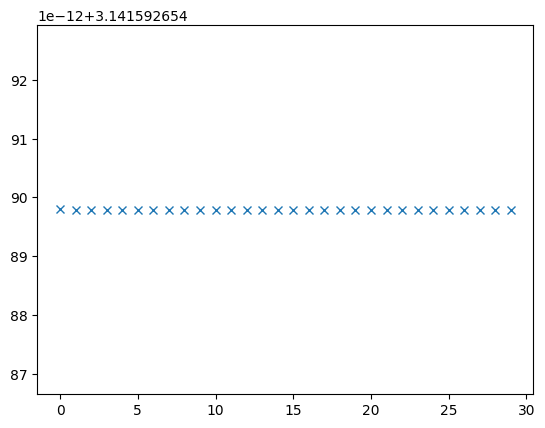

In [22]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rc("text", usetex=False)

n = 100
a = [[1.0/(i-j+0.5) for i in range(n)] for j in range(n)] #Hilbert matrix
# rng_a = np.random.default_rng(46)
# a = np.ones((n, n)) + 1e-3 * rng_a.normal(0, 1, (n, n))
a = np.array(a)
u, s, v = np.linalg.svd(a)
print(s[50] - np.pi)
plt.plot(s[:30], 'x')
print(s)
# plt.ylabel(r"$\sigma_i / \sigma_0$", fontsize=24)
# plt.xlabel(r"Singular value index, $i$", fontsize=24)
# plt.grid(True)
# plt.xticks(fontsize=26)
# plt.yticks(fontsize=26)
# #We have very good low-rank approximation of it!

### Function approximation

1.8004870353547634e-07


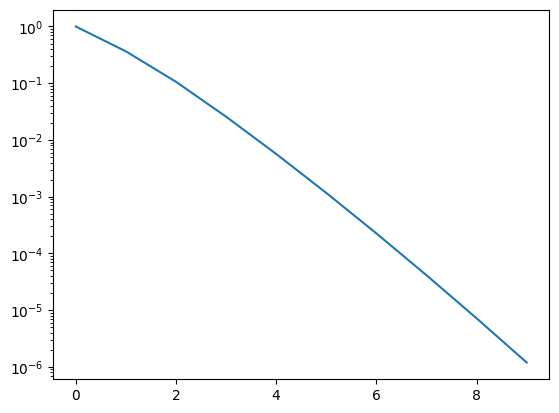

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
n = 128
t = np.linspace(0, 5, n)
x, y = np.meshgrid(t, t)
f = 1.0 / (x + y + 0.01) # test your own function. Check 1.0 / (x - y + 0.5)
u, s, v = np.linalg.svd(f, full_matrices=False)
r = 10
u = u[:, :r]
s = s[:r]
v = v[:r, :] # Mind the transpose here!
fappr = (u * s[None, :]) @ v
er = np.linalg.norm(fappr - f, 'fro') / np.linalg.norm(f, 'fro')
print(er)
plt.semilogy(s/s[0]);
#plt.ylabel(r"$\sigma_i / \sigma_0$", fontsize=24)
#plt.xlabel(r"Singular value index, $i$", fontsize=24)
#plt.grid(True)
#plt.xticks(fontsize=26)
#plt.yticks(fontsize=26)

## And 3d plots...

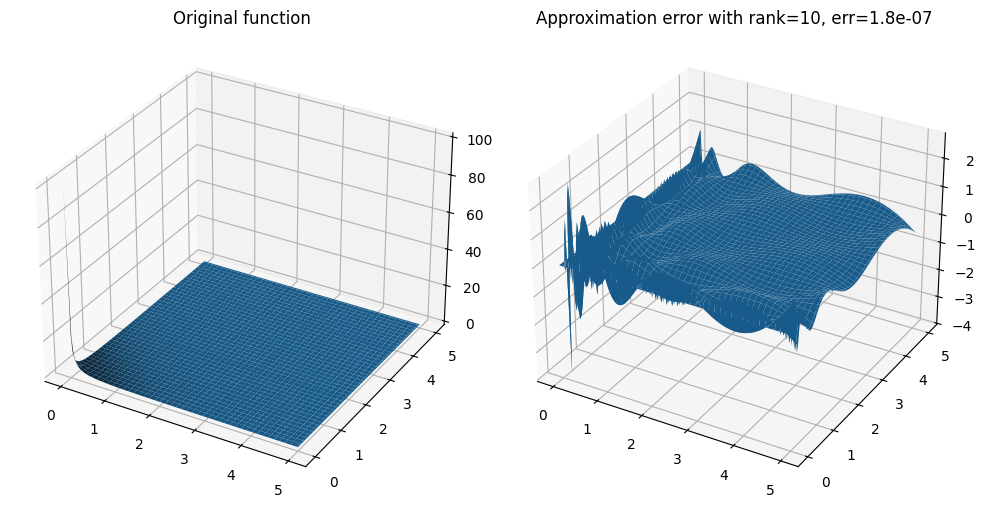

In [26]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# plt.xkcd()
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(x, y, f)
ax.set_title('Original function')
ax = fig.add_subplot(122, projection='3d')
ax.plot_surface(x, y, fappr - f)
ax.set_title('Approximation error with rank=%d, err=%3.1e' % (r, er))
fig.subplots_adjust()
fig.tight_layout()

## Singular values of a random Gaussian matrix

What is the singular value decay of a random matrix?

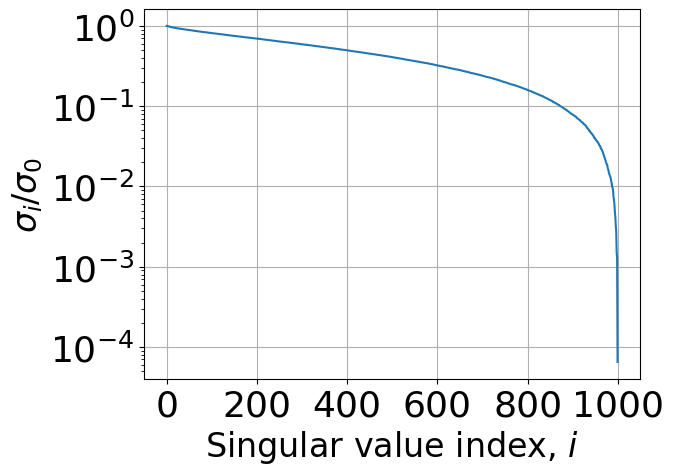

In [2]:
import numpy as np
import matplotlib.pyplot as plt
n = 1000
rng_a = np.random.default_rng(47)
a = rng_a.normal(0, 1, (n, n))
u, s, v = np.linalg.svd(a)
plt.semilogy(s/s[0])
plt.ylabel(r"$\sigma_i / \sigma_0$", fontsize=24)
plt.xlabel(r"Singular value index, $i$", fontsize=24)
plt.grid(True)
plt.xticks(fontsize=26)
plt.yticks(fontsize=26);

## Linear factor analysis & low-rank
Consider a linear factor model, 

$$y = Ax, $$ 

where $y$ is a vector of length $n$, and $x$ is a vector of length $r$.  
The data is organized as samples: we observe vectors  

$$y_1, \ldots, y_T,$$

but do not know matrix $A$,
then the factor model can be written as  

$$
  Y = AX,
$$

where $Y$ is $n \times T$, $A$ is $n \times r$ and $X$ is $r \times T$. 

- This is exactly a rank-$r$ model: it tells us that the vectors lie in a small subspace.
- We also can use SVD to recover this subspace (but not the independent components). 
- Principal component analysis can be done by SVD, checkout the implementation in [sklearn package](https://github.com/scikit-learn/scikit-learn/blob/0d378913be6d7e485b792ea36e9268be31ed52d0/sklearn/decomposition/_pca.py#L465).

## Applications of SVD

- SVD is extremely important in computational science and engineering.

- It has many names: Principal component analysis, Proper Orthogonal Decomposition, Empirical Orthogonal Functions

- Now we will consider compression of **dense** matrix and active subspaces method 

## Dense matrix compression

Dense matrices typically require $N^2$ elements to be stored. A rank-$r$ approximation can reduces this number to $\mathcal{O}(Nr)$

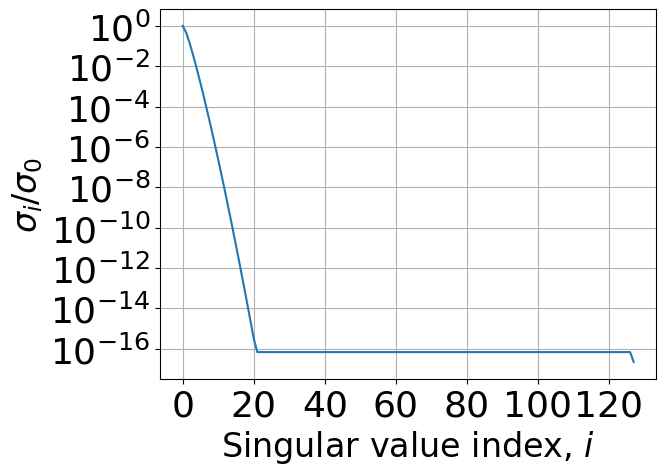

In [6]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

n = 256
a = [[1.0/(i - j + 0.5) for i in range(n)] for j in range(n)]
a = np.array(a)
# u, s, v = np.linalg.svd(a)
u, s, v = np.linalg.svd(a[n//2:, :n//2])
plt.semilogy(s/s[0])
plt.ylabel(r"$\sigma_i / \sigma_0$", fontsize=24)
plt.xlabel(r"Singular value index, $i$", fontsize=24)
plt.grid(True)
plt.xticks(fontsize=26)
plt.yticks(fontsize=26);
#s[0] - np.pi
#u, s, v = np.linalg.svd(a[:128:, :128])
#print(s[0]-np.pi)

## Compression of parameters in fully-connected neural networs

- One of the main building blocks of the modern deep neural networks is **fully-connected layer** a.k.a. **linear layer**
- This layer implements the action of a linear function to an input vector: $f(x) = Wx + b$, where $W$ is a trainable matrix and $b$ is a trainable bias vector
- Both $W$ and $b$ are updated during training of the network according to some optimization method, i.e. SGD, Adam, etc...
- However, the storing of the trained optimal parameters ($W$ and $b$) can be **prohibitive** if you want to port your trained network to the device, where memory is limited
- As a possible recipe, you can **compress** matrices $W_i$ from the $i$-th linear layer with the truncated SVD based on the singular values!
- What do you get after such apprioximation of $W$?
    - memory efficient storage
    - faster inference
    - moderate degradation of the accuracy in solving the target task, i.e. image classification
    

## Active Subspaces 

- Suppose, we are given a function $f(x), \ x \in \mathcal{X} \subseteq \mathbb{R}^{n}$ and want find its low-dimensional parametrization. 
Here $\mathcal{X}$ is the domain of $f(x)$. 

- Informally, we are searching for the directions in which a $f(x)$ changes a lot on average and for the directions in which $f(x)$ is almost constant. 

- Formally, we assume that there is a matrix $W \in \mathbb{R}^{r \times n}$ and a function $g: \mathbb{R^r} \to \mathbb{R}$, such that for every $x \in \mathcal{X}$

$$
f(x)
\approx
g(W x).
$$

### How to discover Active Subspaces:

<u>Using SVD</u>:
1. Choose $m$, the number of estimations. This hyperparameter stands for the number of Monte Carlo estimations. The larger $m$, the more accurate the result is.
2. Draw samples $\lbrace x_i \rbrace_{i = 1}^{m}$ from $\mathcal{X}$ (according to some prior probability density function)
3. For each $x_i$ compute $\nabla f(x_i)$ 
4. Compute the SVD of the matrix

$$
G
    :=
\dfrac{1}{\sqrt{m}}
\begin{bmatrix}
\nabla f(x_1) & \nabla f(x_2) & \ldots & \nabla f(x_m)
\end{bmatrix}
    \approx
U \Sigma V^\top.
$$

5. Estimate the rank of $G \approx U_r \Sigma_r V_r^\top$. The rank $r$ of the matrix $G$ is the dimensionality of the active subspace.
6. Low-dimensional vectors are estimated as $x_{\text{AS}} = U_r^\top x$. 

For further details, look into the book [„Active Subspaces: Emerging Ideas in Dimension Reduction for Parameter Studies“ (2015) by Paul Constantine](https://epubs.siam.org/doi/book/10.1137/1.9781611973860).

## Take home message
- Matrix rank definition
- Skeleton approximation and dyadic representation of a rank-$r$ matrix
- Singular value decomposition and Eckart-Young theorem
- Three applications of SVD (linear factor analysis, dense matrix compression, active subspaces).

## Next lecture
- Linear systems
- Inverse matrix
- Condition number
- Linear least squares
- Pseudoinverse

##### Questions?

# Lecture 5: Linear systems

## Previous lecture
- Matrix rank
- Skeleton decomposition
- Low-rank approximation
- Singular Value Decomposition (SVD)

## Today lecture

- Linear systems
- Inverse matrix
- Condition number
- Gaussian elimination

## Linear systems

- Linear systems of equations are the basic tool in NLA.

- They appear as:

    - Linear regression problems
    - Discretization of partial differential/integral equations
    - Linearizations of nonlinear regression problems
    - Optimization (i.e., Gauss-Newton and Newton-Raphson methods, KKT)

## Linear equations and matrices
- From school we know about linear equations. 

- A linear system of equations can be written in the form

\begin{align*}
    &2 x + 3 y = 5\quad &\longrightarrow \quad &2x + 3 y + 0 z = 5\\
    &2 x + 3z = 5\quad &\longrightarrow\quad &2 x + 0 y + 3 z = 5\\
    &x + y = 2\quad &\longrightarrow\quad  & 1 x + 1 y + 0 z = 2\\
\end{align*}

## Matrix form

$$
\begin{pmatrix}
2 & 3 & 0 \\
2 & 0 & 3 \\
1 & 1 & 0 \\
\end{pmatrix}\begin{pmatrix}
x \\
y \\
z 
\end{pmatrix} = 
\begin{pmatrix}
5 \\
5 \\
2
\end{pmatrix}
$$

or simply

$$ A u = f,  $$

where $A$ is a $3 \times 3$ matrix and $f$ is right-hand side

## Over/under determined linear systems

If the system $Au = f$ has

-  more equations than unknowns it is called **overdetermined** system (generically, no solution)

- less equations than unknowns it is called **underdetermined** system (solution is non-unique, to make it unique additional assumptions have to be made)

## Existence of solutions 

A solution to the linear system of equations with a **square** matrix $A$

$$A u = f$$

exists, iff 
* $\det A \ne 0$

or

* matrix $A$ has full rank.

## Scales of linear systems

In different applications, the typical size of the linear systems can be different. 

- Small: $n \leq 10^4$ (full matrix can be stored in memory, **dense matrix**)
- Medium: $n = 10^4 - 10^6$ (typically, **sparse** or **structured** matrix)
- Large: $n = 10^8 - 10^9$ (typically **sparse** matrix + parallel computations)

## Linear systems can be big
- We take a continious problem, discretize it on a mesh with $N$ elements and get a linear system with $N\times N$ matrix.  
- Example of a mesh around A319 aircraft
(taken from [GMSH website](http://geuz.org/gmsh/)).  
<img src="misc/a319_4.png" width=50%>

The main difficulty is that these systems are big: millions or billions of unknowns!

## Linear systems can be structured

- Storing $N^2$ elements of a matrix is prohibitive even for $N = 100000$.  

**Q:** how to work with such matrices?  

**A:** fortunately, those matrices are **structured** and require $\mathcal{O}(N)$ parameters to be stored.  

- The most widespread structure are **sparse matrices**: such matrices have only $\mathcal{O}(N)$ non-zeros!  

- Example (one of the famous matrices around for $n = 5$):

$$
  \begin{pmatrix}
  2 & -1 & 0 & 0 & 0 \\
  -1 & 2 & -1 & 0 & 0 \\
  0 & -1 & 2 & -1 & 0 \\
  0 & 0 &-1& 2 & -1  \\
  0 & 0 & 0 & -1 & 2 \\
  \end{pmatrix}
$$

- At least you can store such matrices
- Also you can multiply such matrix by vector fast
- But how to solve linear systems?

## Main questions about linear systems

1. What is the accuracy we get from the solution (due to rounding errors)?
2. How we compute the solution? (LU-decomposition, Gaussian elimination)
3. What is the complexity of the solution of linear systems?

## How to solve linear systems?
**Important**: forget about determinants and the **Cramer rule** (it is  good for $2 \times 2$ matrices still)!

## How to solve linear systems?

The main tool is variable elimination. 

\begin{align*}
    &2 y + 3 x = 5 \quad&\longrightarrow \quad &y = 5/2 -  3/2 x \\
    &2 x + 3z = 5 \quad&\longrightarrow\quad &z = 5/3 - 2/3 x\\
    &z + y = 2 \quad&\longrightarrow\quad  & 5/2 + 5/3 - (3/2 + 2/3) x = 2,\\
\end{align*}

and that is how you find $x$ (and all previous ones).  

This process is called **Gaussian elimination** and is one of the most widely used algorithms. 

## Gaussian elimination
Gaussian elimination consists of two steps:
1. Forward step
2. Backward step

## Forward step
- In the forward step, we eliminate $x_1$:

$$
   x_1 = f_1 - (a_{12} x_2 + \ldots + a_{1n} x_n)/a_{11},
$$

and then substitute this into the equations $2, \ldots, n$. 

- Then we eliminate $x_2$ and so on from the second equation. 

- The important thing is that the **pivots** (that we divide over) are not equal to $0$.

## Backward step
In the backward step:
- solve equation for $x_n$
- put it into the equation for $x_{n-1}$ and so on, until we 
compute all $x_i, i=1,\ldots, n$.

## Gaussian elimination and LU decomposition

- Gaussian elimination is the computation of one of the most important matrix decompositions: **LU-decomposition**.

**Definition**: LU-decomposition of the square matrix $A$ is the representation

$$A =  LU,$$

where 
- $L$ is **lower triangular** (elements strictly above the diagonal are zero)
- $U$ is **upper triangular** matrix (elements strictly below the diagonal are zero)

This factorization is **non-unique**, so it is typical to require that the matrix $L$ has ones on the diagonal.

**Main goal** of the LU decomposition is to solve linear system, because

$$ A^{-1} f = (L U)^{-1} f = U^{-1} L^{-1} f, $$

and this reduces to the solution of two linear systems **forward step**

$$ L y = f, $$

and **backward step**

$$ U x = y. $$

Does $LU$ decomposition always exist?

## Complexity of the Gaussian elimination/LU decomposition

- Each elimination step requires $\mathcal{O}(n^2)$ operations. 

- Thus, the cost of the naive algorithm is $\mathcal{O}(n^3)$.  

**Think a little bit**: can Strassen algorithm help here? 

## Block LU-decomposition

We can try to compute **block** version of LU-decomposition:


$$\begin{pmatrix} A_{11} & A_{12} \\
A_{21} & A_{22}
\end{pmatrix} = \begin{pmatrix} L_{11} & 0 \\
L_{21} & L_{22}
\end{pmatrix} \begin{pmatrix} U_{11} & U_{12} \\
0 & U_{22} 
\end{pmatrix} $$

- There are two basic operations: compute LU-factorization of half-matrices + matrix-by-matrix product.

## Existence of the LU-decomposition
- The LU-decomposition algorithm does not fail if **we do not divide by zero** at every step of the Gaussian elimination.

**Q:** when it is so, for which class of matrices?

**A:** it is true for **strictly regular matrices**.

## Strictly regular matrices and LU decomposition 

- **Definition.** A matrix $A$ is called *strictly regular*, if all of its **leading principal minors** (i.e, submatrices in the first $k$ rows and $k$ columns) are non-singular. 

- In this case, there always exists an LU-decomposition. The reverse is also true (check!).

**Corollary:** If $L$ is unit triangular (ones on the diagonal), then $LU$-decomposition is unique. <br>

**Proof:** Indeed, $L_1 U_1 = L_2 U_2$ means $L_2^{-1} L_1 = U_2 U_1^{-1}$. $L_2^{-1} L_1 $ is lower triangular with ones on the diagonal. $U_2 U_1^{-1}$ is upper triangular. Thus, $L_2^{-1} L_1 = U_2 U_1^{-1} = I$ and $L_1 = L_2$, $U_1 = U_2$.

## LU for positive definite Hermitian matrices (Cholesky factorization)

- Strictly regular matrices have LU-decomposition. 

- An important **subclass** of strictly regular matrices is the class of **Hermitian positive definite matrices**


**Definition.** A matrix $A$ is called <font color='red'> positive definite </font> if for any $x: \Vert x \Vert \ne 0$ we have

$$
(x, Ax) > 0.
$$
- if this holds for $x \in \mathbb{C}^n$, then the matrix $A$ has to be hermitian
- if this holds for $x \in \mathbb{R}^n$, then the matrix $A$ can be non symmetric

- **Claim:** A Hermitian positive definite matrix $A$ is strictly regular and has **Cholesky factorization** of the form 

$$A = RR^*,$$

where $R$ is a lower triangular matrix.

- Let us try to prove this fact (on the whiteboard).

- It is sometimes referred to as "square root" of the matrix.

## Computing LU-decomposition

- In many cases, computing LU-decomposition once is a good idea!

- Once the decomposition is found (it costs $\mathcal{O}(n^3)$ operations), then solving linear systems with $L$ and $U$ costs only $\mathcal{O}(n^2)$ operations.

**Check:**

- Solving linear systems with triangular matrices is easy (why?). 
- How we compute the $L$ and $U$ factors?

## When LU fails

- What happens, if the matrix is not strictly regular (or the **pivots** in the Gaussian elimination are really small?). 

- There is classical $2 \times 2$ example of a matrix with a bad LU decomposition.  

- The matrix we look at is  

$$
    A = \begin{pmatrix}
    \varepsilon & 1 \\
    1 & 1 
    \end{pmatrix}
$$

- If $\varepsilon$ is sufficiently small, we **might** fail. In contrast the Cholesky factorization is **always stable**.

- Is LU factorization forward or backward stable?

Let us do some demo here.

In [5]:
import numpy as np

eps = 1.8e-17
a = [[eps, 1],[1.0,  1]]
a = np.array(a)
a0 = a.copy()
n = a.shape[0]
L = np.zeros((n, n))
U = np.zeros((n, n))
for k in range(n): #Eliminate one row
    L[k, k] = 1.0
    for i in range(k+1, n):
        L[i, k] = a[i, k] / a[k, k]
        for j in range(k+1, n):
            a[i, j] -= L[i, k]*a[k, j]
    for j in range(k, n):
        U[k, j] = a[k, j]
print('L * U - A:\n', np.dot(L, U) - a0)
print(L)

L * U - A:
 [[ 0.  0.]
 [ 0. -1.]]
[[1.00000000e+00 0.00000000e+00]
 [5.55555556e+16 1.00000000e+00]]


### Numerical stability of LU and Cholesky for hermitian positive definite matrices

- Assume input is a block matrix: $A = \begin{pmatrix} a_{11} & {a_{12}}^* \\ a_{12} & A_{22} \end{pmatrix}$

- Perform a single Gauss Elimination step:
  $A = \begin{pmatrix} \sqrt{a_{11}} & 0 \\ \frac{a_{12}}{\sqrt{a_{11}}} & A_{22} - \frac{a_{12} {a_{12}}^*}{a_{11}} \end{pmatrix} \begin{pmatrix} \sqrt{a_{11}} & \frac{{a_{12}}^*}{\sqrt{a_{11}}} \\ 0 & I \end{pmatrix}$

- Estimate Frobenius norm of the remainder:
  $\left\| A_{22} - \frac{a_{12} {a_{12}}^*}{a_{11}} \right\|_F \le \left\| A_{22} \right\|_F$

- Hint: $a_{12} \left( A_{22} - \frac{a_{12} {a_{12}}^*}{a_{11}} \right) {a_{12}}^* \ge 0$

- Numerical stability comes from upper-bounded norm of the remainder

## The concept of pivoting

- We can do pivoting, i.e. permute rows and columns to maximize $A_{kk}$ that we divide over.  

- The simplest but effective strategy is the **row pivoting**: at each step, select the index that is maximal in modulus, and put it onto the diagonal. 

- It gives us the decomposition 

$$A = P L U,$$

where $P$ is a **permutation matrix**.


**Q.** What makes **row pivoting** good?  

**A.** It is made good by the fact that  

$$ | L_{ij}|<1, $$

but the elements of $U$ can grow, up to $2^n$! (in practice, this is very rarely encountered).

- Can you come up with a matrix where the elements of $U$ grow as much as possible?

## Stability of linear systems

- There is a fundamental problem of solving linear systems which is independent on the algorithm used.

- It occures when elements of a matrix are represented as floating point numbers or there is some measurement noise.

Let us illustrate this issue on the following example.

51.34605128237216


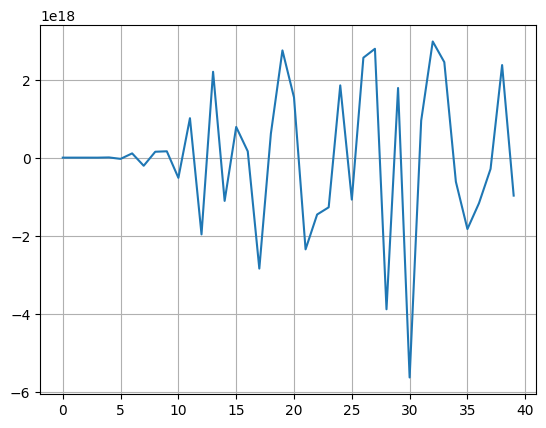

In [9]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

n = 40
a = [[1.0/(i + j + 0.5) for i in range(n)] for j in range(n)]
a = np.array(a)
rng_rhs = np.random.default_rng(42)
rhs = rng_rhs.normal(0, 1, (n,)) #Right-hand side
x = np.linalg.solve(a, rhs) #This function computes LU-factorization and solves linear system

#And check if everything is fine
er = np.linalg.norm(a.dot(x) - rhs) / np.linalg.norm(rhs)
print(er)
plt.plot(x)
plt.grid(True);

- As you see, the error grows with larger $n$, and we have to find out why.  
- **Important point** is that it is not a problem of the algorithm: it is a problem of representing the matrix in the memory. 
- The error occurs in the moment when the matrix elements are evaluated approximately.

## Questions from the demo

- What was the problem in the previous example? 

- Why the error grows so quickly?  

- And here is one of the main concepts of numerical linear algebra: the concept of **condition number** of a matrix.  

But before that we have to define the **inverse**. 

## Inverse: definition

- The inverse of a matrix $A$ is defined as a matrix $X$ denoted by $A^{-1}$ such that  

$$ AX = XA = I,  $$

where $I$ is the identity matrix (i.e., $I_{ij} = 0$ if $i \ne j$ and $1$ otherwise).
- The computation of the inverse is linked to the solution of linear systems.  Indeed, the $i$-th column of the product gives  

$$ A x_i = e_i,$$

where $e_i$ is the $i$-th column of the identity matrix. 
- Thus, we can apply Gaussian elimination to solve this system. Moreover, if there are no divisions by zero in this process (and the pivots do not depend on the right-hand side), then it is possible to solve the system.

## Inverse matrix and linear systems
If we have computed $A^{-1}$, the solution of linear system  

$$Ax = f$$

is just $x = A^{-1} f$.  

Indeed,  

$$ A(A^{-1} f) = (AA^{-1})f = I f = f. $$

## Neumann series 

- To study, why there can be such big errors in a solution (see the example above on the Hilbert matrix) we need an important auxiliary result.  

**Neumann series**:  

If a matrix $F$ is such that $\Vert F \Vert < 1$ holds, then the matrix $(I - F)$ is invertible and

$$(I - F)^{-1} = I + F + F^2 + F^3 + \ldots = \sum_{k=0}^{\infty} F^k.$$

Note that it is a matrix version of the geometric progression. 

**Q**: Does this series converge if $\| F \| > 1$ and $\| F^2 \| < 1$? What about $\| F^k \| < 1$ for arbitrary $k$?

**Q**: What norm is considered here? What is the "best possible" norm here?

**Q**: Is there a limit $\lim_{k\rightarrow\infty} \| F^k \|^\frac{1}{k}$? How is it called?

## Proof
The proof is constructive. First of all, prove that the series $\sum_{k=0}^{\infty} F^k$ converges.  

Like in the scalar case, we have  

$$ (I - F) \sum_{k=0}^N F^k = (I - F^{N+1}) \rightarrow I, \quad N \to +\infty $$

Indeed, 

$$ \| (I - F^{N+1}) - I\| = \|F^{N+1}\| \leqslant \|F\|^{N+1} \to 0, \quad N\to +\infty. $$

We can also estimate the **norm of the inverse**:

$$ \left\Vert \sum_{k=0}^N F^k \right\Vert \leq \sum_{k=0}^N \Vert F \Vert^k \Vert I \Vert \leq \frac{\Vert I \Vert}{1 - \Vert F \Vert} $$

## Small perturbation of the inverse

- Using this result, we can estimate, how the perturbation of the matrix influences the inverse matrix. 
- We assume that the perturbation $E$ is small in the sense that $\Vert A^{-1} E \Vert < 1$. 
- Then

$$(A + E)^{-1} = \sum_{k=0}^{\infty} (-A^{-1} E)^k A^{-1}$$

and moreover, 

$$ \frac{\Vert (A + E)^{-1} - A^{-1} \Vert}{\Vert A^{-1} \Vert} \leq \frac{\Vert A^{-1} \Vert \Vert E \Vert \Vert I \Vert}{1 - \Vert A^{-1} E \Vert}. $$

As you see, the norm of the inverse enters the estimate.

## Condition number of a linear system
Now consider the **perturbed** linear system:

$$ (A + \Delta A) \widehat{x} = f + \Delta f. $$

## Estimates

$$
\begin{split}
\widehat{x} - x &= (A + \Delta A)^{-1} (f + \Delta f) - A^{-1} f =\\ 
&= \left((A + \Delta A)^{-1} - A^{-1}\right)f + (A + \Delta A)^{-1} \Delta f = \\
& = \Big[ \sum_{k=0}^{\infty} (-A^{-1} \Delta A)^k - I \Big]A^{-1} f + \Big[\sum_{k=0}^{\infty} (-A^{-1} \Delta A)^k \Big]A^{-1} \Delta f  \\
&= \Big[\sum_{k=1}^{\infty} (-A^{-1} \Delta A)^k\Big] A^{-1} f + \Big[\sum_{k=0}^{\infty} (-A^{-1} \Delta A)^k \Big] A^{-1} \Delta f,
\end{split}
$$   

therefore

$$
\begin{split}
\frac{\Vert \widehat{x} - x \Vert}{\Vert x \Vert} \leq 
&\frac{1}{\|A^{-1}f\|} \Big[ \frac{\|A^{-1}\|\|\Delta A\|}{1 - \|A^{-1}\Delta A\|}\|A^{-1}f\| + \frac{1}{1 - \|A^{-1} \Delta A\|} \|A^{-1} \Delta f\|  \Big] \\
\leq & \frac{\|A\|\|A^{-1}\|}{1 - \|A^{-1}\Delta A\|} \frac{\|\Delta A\|}{\|A\|} + \frac{\|A^{-1}\|}{1 - \|A^{-1}\Delta A\|} \frac{\|\Delta f\|}{\|A^{-1}f\|}\\
\end{split}
$$

Note that $\|AA^{-1}f\| \leq \|A\|\|A^{-1}f\|$, therefore $\| A^{-1} f \| \geq \frac{\|f\|}{\|A\|}$

Now we are ready to get the final estimate

$$
\begin{split}
\frac{\Vert \widehat{x} - x \Vert}{\Vert x \Vert} \leq 
&\frac{\Vert A \Vert \Vert A^{-1} \Vert}{1 - \|A^{-1}\Delta A\|} \Big(\frac{\Vert\Delta A\Vert}{\Vert A \Vert} + \frac{\Vert \Delta f \Vert}{ \Vert f \Vert}\Big) \leq \\
\leq
&\frac{\Vert A \Vert \Vert A^{-1} \Vert}{1 - \|A\|\|A^{-1}\|\frac{\|\Delta A\|}{\|A\|}} \Big(\frac{\Vert\Delta A\Vert}{\Vert A \Vert} + \frac{\Vert \Delta f \Vert}{ \Vert f \Vert}\Big) \equiv \\
\equiv &\frac{\mathrm{cond}(A)}{1 - \mathrm{cond}(A)\frac{\|\Delta A\|}{\|A\|}} \Big(\frac{\Vert\Delta A\Vert}{\Vert A \Vert} + \frac{\Vert \Delta f \Vert}{ \Vert f \Vert}\Big)
\end{split}
$$

The crucial role is played by the **condition number** $\mathrm{cond}(A) = \Vert A \Vert \Vert A^{-1} \Vert$.

## Condition number 

- The larger the condition number, the less number of digits we can recover. Note, that the condition number is different for different norms.

- Note, that if $\Delta A = 0$, then

$$ \frac{\Vert \widehat{x} - x \Vert}{\Vert x \Vert} \leq \mathrm{cond}(A) \frac{\|\Delta f\|}{\|f\|} $$

- The spectral norm of the matrix is equal to the **largest singular value**, and the singular values of the inverse matrix are equal to the inverses of the singular values.  
- Thus, the condition number in spectral norm is equal to the ratio of the largest singular value and the smallest singular value.

$$ \mathrm{cond}_2 (A) = \|A\|_2 \|A^{-1}\|_2 = \frac{\sigma_{\max}}{\sigma_{\min}} $$

## Hilbert matrix (again)

- We can also try to test how tight is the estimate, both with ones in the right-hand side, and with a random vector in the right-hand side. 
- The results are strickingly different

In [ ]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

n = 40
a = [[1.0/(i + j + 0.5) for i in range(n)] for j in range(n)]
a = np.array(a)
rhs = np.ones(n) #Right-hand side
#rhs = np.arange(n)
#rhs = (-1)**rhs
f = np.linalg.solve(a, rhs)

#And check if everything is fine
er = np.linalg.norm(a.dot(f) - rhs) / np.linalg.norm(rhs)
cn = np.linalg.cond(a, 2)
print('Error:', er, 'Log Condition number:', np.log10(cn))
print('Log of norm of solution: ', np.log(np.linalg.norm(f)))
u1, s1, v1 = np.linalg.svd(a)
# cf = u1.T@rhs
# plt.plot(u1[:, 12]);
# print(cf/s1)
# print(np.linalg.norm(rhs.T @ a))

Error: 5.5254984550890796e-08 Log Condition number: 19.707825809438148
Log of norm of solution:  23.594978142073224
10.951489957311837


And with random right-hand side...

Error: 19.80622678695902 Condition number: 3.4840276761605435e+19
Log of norm of solution:  43.25248282250902
0.5470733200924179


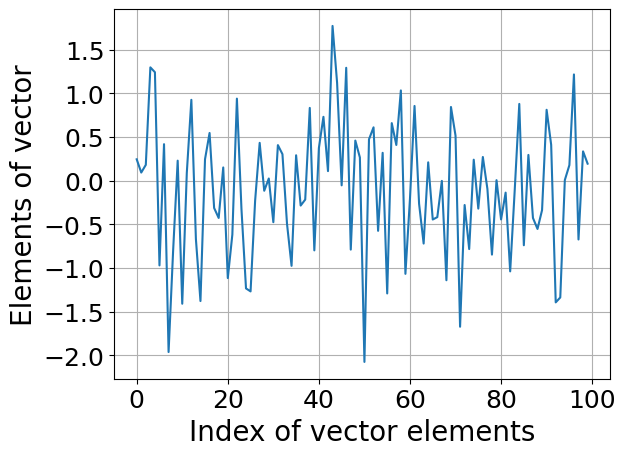

In [ ]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

n = 100
a = [[1.0/(i + j + 1) for i in range(n)] for j in range(n)]
a = np.array(a)
rng_rhs = np.random.default_rng(42)
rhs = rng_rhs.normal(0, 1, (n, )) #Right-hand side
f = np.linalg.solve(a, rhs)

#And check if everything is fine
er = np.linalg.norm(a.dot(f) - rhs) / np.linalg.norm(rhs)
cn = np.linalg.cond(a)
print('Error:', er, 'Condition number:', cn)
print('Log of norm of solution: ', np.log(np.linalg.norm(f)))

u, s, v = np.linalg.svd(a)
plt.plot(u.T.dot(rhs))
plt.grid(True)
plt.xlabel("Index of vector elements", fontsize=20)
plt.ylabel("Elements of vector", fontsize=20)
plt.xticks(fontsize=18)
_ = plt.yticks(fontsize=18);
# print(np.linalg.norm(rhs.T @ a))

**Can you think about an explanation?**  

## Overdetermined linear systems

- Important class of problems are **overdetermined linear systems**, when the number of equations is greater, than the number of unknowns. 

- The simplest example that you all know, is **linear fitting**, fitting a set of 2D points by a line.

- Then, a typical way is to minimize the residual (**least squares**)

$$\Vert A x - b \Vert_2 \rightarrow \min$$

## Overdetermined system and Gram matrix

The optimality condition is $0\equiv \nabla \left(\|Ax-b\|_2^2\right)$, where $\nabla$ denotes gradient. Therefore,

$$ 0 \equiv \nabla \left(\|Ax-b\|_2^2\right) = 2(A^*A x - A^*b) = 0. $$

Thus,

$$ \quad A^* A x = A^* b $$

- The matrix $A^* A$ is called **Gram matrix** and the system is called **normal equation**. 

- This is not a good way to do it, since the condition number of $A^* A$ is a square of condition number of $A$ (check why).

## Pseudoinverse

- Matrix $A^* A$ can be singular in general case. 
- Therefore, we need to introduce the concept of pseudoinverse matrix  $A^{\dagger}$ such that solution of the linear least squares problem can formally be written as

$$x = A^{\dagger} b.$$

- The matrix $$A^{\dagger} = \lim_{\alpha \rightarrow 0}(\alpha I + A^* A)^{-1} A^*$$ is called **Moore-Penrose** pseudoinverse of the matrix $A$.

- If matrix $A$ has full column rank, then $A^* A$ is non-singular and we get 

$$A^{\dagger} = \lim_{\alpha \rightarrow 0}(\alpha I + A^* A)^{-1} A^* = (A^* A)^{-1} A^*. $$

- If matrix $A$ is squared and non-singular we get standard inverse of $A$:

$$A^{\dagger} = \lim_{\alpha \rightarrow 0}(\alpha I + A^* A)^{-1} A^* = (A^* A)^{-1} A^* = A^{-1} A^{-*} A^* = A^{-1}$$

* If $A$ has linearly dependent columns, then $A^\dagger b$ gives solution that has minimal Euclidean norm 

## Compute pseudoinverse via SVD
Let $A = U \Sigma V^*$ be the SVD of $A$. Then,

$$A^{\dagger} = V \Sigma^{\dagger} U^*,$$

where $\Sigma^{\dagger}$ consists of inverses of non-zero singular values of $A$. Indeed,

\begin{align*}
A^{\dagger} &= \lim_{\alpha \rightarrow 0}(\alpha I + A^* A)^{-1} A^* = \lim_{\alpha \rightarrow 0}( \alpha VV^* + V \Sigma^2 V^*)^{-1} V \Sigma U^* \\ & = \lim_{\alpha \rightarrow 0}( V(\alpha I + \Sigma^2) V^*)^{-1} V \Sigma U^* = V \lim_{\alpha \rightarrow 0}(\alpha I + \Sigma^2)^{-1} \Sigma U^* = V \Sigma^{\dagger} U^*.
\end{align*}

* One can check that $\Sigma^{\dagger}$ contains just the inversion of nonzero singular values.
* If singular values are small, one can skip inverting them. This will result in a solution which is less sensitive to the noise in the right-hand side.
* The condition number for the Euclidean norm is still just the ratio of the largest and the  smallest non-zero singular values.

## A canonical way to solve linear least squares

Is to use the $QR$ decomposition.

- Any matrix can be factored into a product 

$$ A = Q R, $$

where $Q$ is unitary, and $R$ is upper triangular (details in the next lectures).

- Then, if $A$ has full column rank, then

$$ x = A^{\dagger}b = (A^*A)^{-1}A^*b = ((QR)^*(QR))^{-1}(QR)^*b = (R^*Q^*QR)^{-1}R^*Q^*b = R^{-1}Q^*b.  $$

- Thus, finding optimal $x$ is equivalent to solving 

$$ Rx = Q^* b. $$

- Since $R$ is upper triangular, the solving of this linear system costs $\mathcal{O}(n^2)$. 
- Also it is more stable, than using the pseudo-inverse matrix directly. 

## Padding into a bigger system

- Instead of solving $A^* A x = A^* b$, we introduce a new variable $r = Ax - b$ and then have

$$A^* r = 0, \quad r = Ax - b,$$

or in the block form

$$ \begin{pmatrix} 0 & A^* \\ A & -I \end{pmatrix} \begin{pmatrix} x \\ r \end{pmatrix} = \begin{pmatrix} 0 \\ b \end{pmatrix}, $$  

the total size of the system is $(n + m)$ square, and the condition number is the same as for $A$ 
- How we define the condition number of a rectangular matrix?


## Example of LS
Consider a two-dimensional example. Suppose we have a linear model 

$$y = ax + b$$

and noisy data $(x_1, y_1), \dots (x_n, y_n)$. Then the linear system on coefficients will look as follows

$$
\begin{split}
a x_1 + b &= y_1 \\
\vdots & \\
a x_n + b &= y_n \\
\end{split}
$$

or in a matrix form

$$
\begin{pmatrix}
x_1 & 1 \\
\vdots & \vdots \\
x_n & 1 \\
\end{pmatrix}
\begin{pmatrix}
a \\
b
\end{pmatrix} =
\begin{pmatrix}
y_1 \\
\vdots  \\
y_n \\
\end{pmatrix},
$$

which represents overdetermined system.

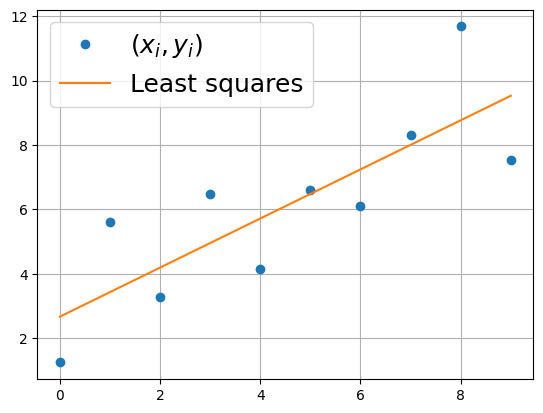

In [35]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

a_exact = 1.
b_exact = 2.

n = 10
xi = np.arange(n)
rng_yi = np.random.default_rng(42)
yi = a_exact * xi + b_exact + 2 * rng_rhs.normal(0, 1, (n, ))

A = np.array([xi, np.ones(n)])
coef = np.linalg.pinv(A).T.dot(yi) # coef is [a, b]

plt.plot(xi, yi, 'o', label='$(x_i, y_i)$')
plt.plot(xi, coef[0]*xi + coef[1], label='Least squares')
plt.legend(loc='best', fontsize=18)
plt.grid(True);

## Lacking for structure

- A typical 3D-problem requires a $100 \times 100 \times 100$ discretization  

- This gives a linear system with $10^6$ unknowns, right-hand side takes $8$ megabytes of memory

- This matrix has $10^6 \times 10^6 = 10^{12}$ elements, takes $8$ terabytes of memory.

Fortunately, the matrices in real-life are not **dense**, but have certain **structure**:

- Sparse matrices
- Low-rank matrices
- Toeplitz matrices (shift-invariant property)
- Sparse in certain bases

## Summary
- Linear systems can be solved by Gaussian elimination, complexity is $\mathcal{O}(n^3)$.
- Linear systems can be solved by LU-decomposition, complexity is $\mathcal{O}(n^3)$ for the decomposition, $\mathcal{O}(n^2)$ for each solve
- Linear least squares can be solved by normal equation (bad)
- Linear least squares can be solved by QR-decomposition (good) or by augmentation (not bad)
- Without structure, we can solve up to $10^4$ linear systems on a laptop (memory restrictions)

## Next lecture
- Eigenvectors & eigenvalues 
- Schur theorem

In [8]:
from IPython.core.display import HTML
def css_styling():
    styles = open("../styles/custom.css", "r").read()
    return HTML(styles)
css_styling()

# Lecture 6: Eigenvalues and eigenvectors

## Recap of the previous lecture
- Linear systems
- Gaussian elimination
- LU decomposition
- Condition number as a measure of forward stability of the problem

## Today lecture
Today we will talk about:
- Eigenvectors and their applications (PageRank)
- Gershgorin circles
- Computing eigenvectors using power method
- Schur theorem
- Normal matrices

## What is an eigenvector?

- **Definition.** A vector $x \ne 0$ is called an **eigenvector** of a square matrix $A$ if there exists a number $\lambda$ such that  

$$ Ax = \lambda x. $$

- The number $\lambda$ is called an **eigenvalue**.  The name **eigenpair** is also used.

- Since $A - \lambda I$ should have a non-trivial kernel, eigenvalues are the roots of the characteristic polynomial

$$ \det (A - \lambda I) = 0.$$

## Eigendecomposition
If matrix $A$ of size $n\times n$ has $n$ eigenvectors $s_i$, $i=1,\dots,n$:

$$ As_i = \lambda_i s_i, $$

then this can be written as

$$ A S = S \Lambda, \quad\text{where}\quad S=(s_1,\dots,s_n), \quad \Lambda = \text{diag}(\lambda_1, \dots, \lambda_n), $$

or equivalently

$$ A = S\Lambda S^{-1}. $$

- This is called **eigendecomposition** of a matrix. Matrices that can be represented by their eigendecomposition are called **diagonalizable**.

### Existence

- What classes of matrices are diagonalizable?

- Simple example can be matrices with all different eigenvalues.
- More generally, matrix is diagonalizable iff **algebraic multiplicity** of each eigenvalue (mutiplicity of eigenvalue in the characteristic polynomial) is equal to its **geometric multiplicity** (dimension of eigensubspace). 

- For our purposes the most important class of diagonalizable matrices is the class of **normal matrices**: 

$$AA^* = A^* A.$$

- You will learn how to prove that normal matrices are diagonalizable after a few slides (Schur decomposition topic).

#### Example

* You can simply check that, e.g. matrix 

$$A = \begin{pmatrix} 1 & 1 \\ 0 & 1 \end{pmatrix}$$ 

has one eigenvalue $1$ of multiplicity $2$ (since its characteristic polynomial is $p(\lambda)=(1-\lambda)^2$), but only one eigenvector $\begin{pmatrix} c \\ 0  \end{pmatrix}$ and hence the matrix is not diagonalizable.

## Why eigenvectors and eigenvalues are important?

- Eigenvectors are both important auxiliary tools and also play important role in applications.  

Can you give some examples?


## Applications of eigenvalues/eigenvectors

- **Communication theory:** theoretical limit on the amount of information transferred
- **Designing bridges** (mechanical engineering)
- **Designing** hifi-audio systems
- **Quantum chemistry:** all our microworld is governed by the **Schrodinger equation** which is an eigenvalue problem:

$$ H \psi = E \psi, $$

- Model order reduction of complex systems
- Graph analysis (PageRank, graph clustering)



## Eigenvalues are vibrational frequencies

A typical computation of eigenvectors / eigenvectors is for studying 

- Vibrational computations of mechanical structures
- Model order reduction of complex systems

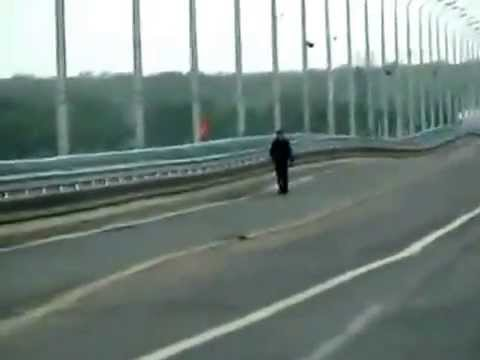

In [1]:
from IPython.display import YouTubeVideo 
YouTubeVideo("VcCcMZo6J6w")

## Google PageRank
- One of the most famous eigenvectors computation is the **Google PageRank**. 
- It is not actively used by Google nowadays, but it was one of the main features in its early stages. The question is how do we rank webpages, which one is important, and which one is not. 
- All we know about the web is which page refers to which. PageRank is defined by a recursive definition. 
- Denote by $p_i$ the **importance** of the $i$-th page. 
- Then we define this importance as an average value of all importances of all pages that refer to the current page. It gives us a linear system  

$$ p_i = \sum_{j \in N(i)} \frac{p_j}{L(j)}, $$

where $L(j)$ is the number of outgoing links on the $j$-th page, $N(i)$ are all the neighbours of the $i$-th page. It can be rewritten as  

$$ p = G p, \quad G_{ij} = \frac{1}{L(j)} $$

or as an eigenvalue problem

$$
   Gp = 1 p,
$$

i.e. the eigenvalue $1$ is already known. Note that $G$ is **left stochastic**, i.e. its columns sum up to $1$. 
Check that any left stochastic matrix has maximum eigenvalue equal to $1$.

## Demo
- We can compute PageRank using some Python packages. 
- We will use ```networkx``` package for working with graphs that can be installed using  

```conda install networkx```

- Other packages to work with graphs in Python are [igraph](https://igraph.org/) and [graph-tool](https://graph-tool.skewed.de/)
- They can be useful in your projects

- We will use a simple example of [Zachary karate club network](https://en.wikipedia.org/wiki/Zachary%27s_karate_club). 
- This data was manually collected in 1977, and is a classical social network dataset.

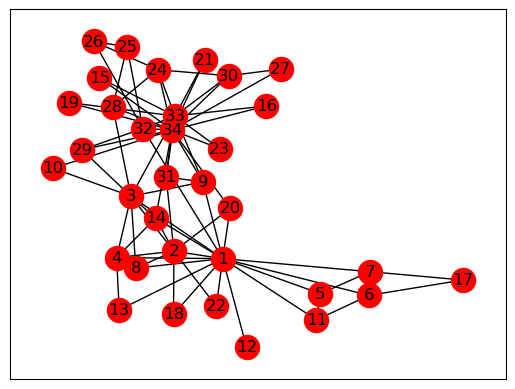

In [2]:
import jax.numpy as jnp
%matplotlib inline
import matplotlib.pyplot as plt
import networkx as nx
kn = nx.read_gml('karate.gml')
#nx.write_gml(kn, 'karate2.gml')
nx.draw_networkx(kn, node_color="red") #Draw the graph

- Now we can actually compute the PageRank using the NetworkX built-in function. 
- We also plot the size of the nodes larger if its PageRank is larger.

Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!
W0000 00:00:1762856087.923300 99068619 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1762856087.935840 99068619 service.cc:145] XLA service 0x600002e74f00 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762856087.935868 99068619 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1762856087.937464 99068619 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1762856087.937476 99068619 mps_client.cc:384] XLA backend will use up to 11452858368 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M2 Pro


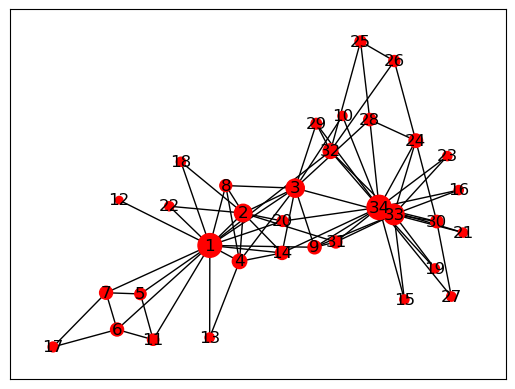

In [3]:
pr = nx.algorithms.link_analysis.pagerank(kn)
pr_vector = list(pr.values())
pr_vector = jnp.array(pr_vector) * 3000
nx.draw_networkx(kn, node_size=pr_vector, node_color="red", labels=None)

## Computations of eigenvalues

- How to compute  eigenvalues and eigenvectors? 

There are two types of eigenproblems:

- full eigenproblem (all eigenvalues & eigenvectors are required)
- partial eigenvalues (minimal/maximal eigenvalues, eigenvalues within the specified region are required)

## Computation of the eigenvalues via characteristic equations
The eigenvalue problem has the form  

$$ Ax = \lambda x, $$

or

$$ (A - \lambda I) x = 0, $$

therefore matrix $A - \lambda I$ has non-trivial kernel and should be singular. 

That means, that the **determinant**  

$$ p(\lambda) = \det(A - \lambda I) = 0. $$

- The equation is called **characteristic equations** and is a polynomial of order $n$. 
- The $n$-degree polynomial has $n$ complex roots!

## Recall the determinant
The determinant of a square matrix $A$ is defined as 

$$\det A = \sum_{\sigma \in S_n} \mathrm{sgn}({\sigma})\prod^n_{i=1} a_{i, \sigma_i},$$

where 
- $S_n$ is the set of all **permutations** of the numbers $1, \ldots, n$
- $\mathrm{sgn}$ is the **signature** of the permutation ( $(-1)^p$, where $p$ is the number of transpositions to be made).

## Properties of determinant
Determinant has many nice properties:

_1._ $\det(AB) = \det(A) \det(B)$

_2._ If we have one row as a sum of two vectors, determinant is a sum of two determinants

_3._ "Minor expansion": we can expand  determinant through a selected row or column.

- If you do it via **minor expansion**, we get **exponential** complexity in $n$.

- Can we do $\mathcal{O}(n^3)$? 

## Eigenvalues and characteristic equation

- Now we go back to the eigenvalues.

- The characteristic equation can be used to compute the eigenvalues, which leads to **na&iuml;ve** algorithm:

$$p(\lambda) = \det(A - \lambda I)$$

1. Compute coefficients of the polynomial
2. Compute the roots

**Is this a good idea**?   

**Give your feedback**

We can do a short demo of this

Text(0, 0.5, 'Imaginary part')

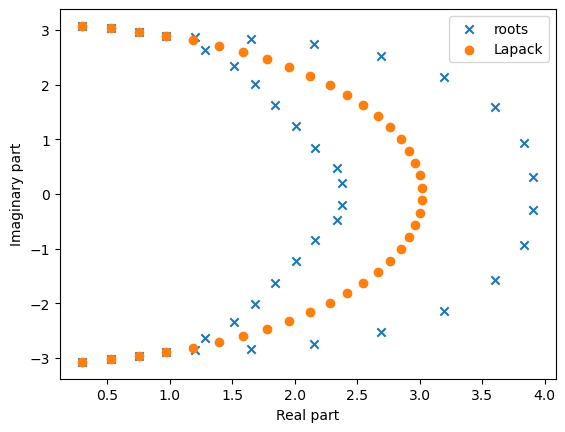

In [6]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax
import numpy as np
n = 40
a = [[1.0 / (i - j + 0.5) for i in range(n)] for j in range(n)]
a = np.array(a)
ev = np.linalg.eigvals(a)
#There is a special numpy function for chacteristic polynomial
cf = np.poly(a)
ev_roots = np.roots(cf)
#print('Coefficients of the polynomial:', cf)
#print('Polynomial roots:', ev_roots)
plt.scatter(ev_roots.real, ev_roots.imag, marker='x', label='roots')
b = a + 0 * np.random.randn(n, n)#jax.random.normal(jax.random.PRNGKey(0,), (n, n))
ev_b = np.linalg.eigvals(b)
plt.scatter(ev_b.real, ev_b.imag, marker='o', label='Lapack')
#plt.scatter(ev_roots.real, ev_roots.imag, marker='o', label='Brute force')
plt.legend(loc='best')
plt.xlabel('Real part')
plt.ylabel('Imaginary part')

### Morale

- Do not do that, unless you have a reason. 
- Polynomial rootfinding is very **ill-conditioned** (can be much better, but not with monomials $\{1,x,x^2,\dots\}$!). Note that Gram matrix of monomials 

$$h_{ij} = \int_0^1 x^i x^j\, dx = \frac{1}{i+j+1},$$

is the Hilbert matrix, which has exponential decay of singular values. 
- So, monomials are "almost" linearly dependent.

## Gershgorin circles
- There is a very interesting theorem that sometimes helps to localize the eigenvalues. 

- It is called **Gershgorin theorem**.  

- It states that all eigenvalues $\lambda_i,  i = 1, \ldots, n$ are located inside the union of **Gershgorin circles** $C_i$,  where $C_i$ is a disk on the complex plane with center $a_{ii}$ and radius  

$$r_i = \sum_{j \ne i} |a_{ij}|.$$

- Moreover, if the circles do not intersect they contain only one eigenvalue per circle. 
- The proof is instructive since it uses the concepts we looked at the previous lectures.

## Proof
First, we need to show that if the matrix $A$ is **strictly diagonally dominant**, i.e. 

$$
   |a_{ii}| > \sum_{j \ne i} |a_{ij}|,
$$
then such matrix is non-singular.

We separate the diagonal part and off-diagonal part, and get  

$$
    A = D + S = D( I + D^{-1}S),
$$

and $\Vert D^{-1} S\Vert_1 < 1$. Therefore, by using the **Neumann series**, the matrix $I + D^{-1}S$ is invertible and hence $A$ is invertible.

Now the proof follows by contradiction: 

- if any of the eigenvalues lies outside all of the circles, the matrix $(A - \lambda I)$ 
is strictly diagonally dominant
- thus it is invertible
- that means, that $(A - \lambda I) x = 0$ means $x = 0$. 

## A short demo

AttributeError: module 'jax.ops' has no attribute 'index_update'

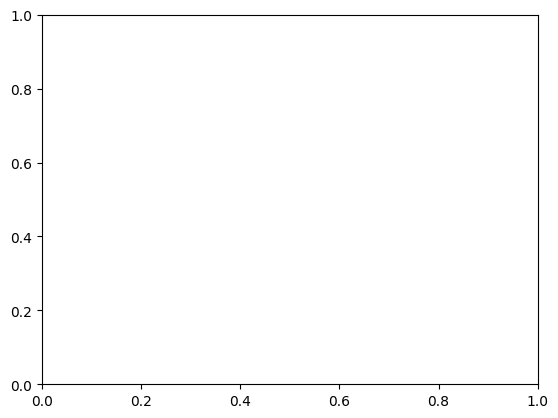

In [7]:
import jax.numpy as jnp
%matplotlib inline
n = 3
fig, ax = plt.subplots(1, 1)
a = [[5, 1, 1], [1, 0, 0.5], [2, 0, 10]]
#a = [[1.0 / (i - j + 0.5) for i in xrange(n)] for j in xrange(n)]
a = jnp.array(a)
#a = np.diag(np.arange(n))
a = a + 2 * jax.random.normal(jax.random.PRNGKey(0), (n, n))
#u = np.random.randn(n, n)
#a = np.linalg.inv(u).dot(a).dot(u)
xg = jnp.diag(a).real
yg = jnp.diag(a).imag
rg = jnp.zeros(n)
ev = jnp.linalg.eigvals(a)
for i in range(n):
    rg = jax.ops.index_update(rg, jax.ops.index[i], jnp.sum(jnp.abs(a[i, :])) - jnp.abs(a[i, i]))
    crc = plt.Circle((xg[i], yg[i]), radius=rg[i], fill=False)
    ax.add_patch(crc)
plt.scatter(ev.real, ev.imag, color='r', label="Eigenvalues")
plt.axis('equal')
plt.legend()
ax.set_title('Eigenvalues and Gershgorin circles')
fig.tight_layout()

**Note**: There are more complicated figures, like **[Cassini ovals](https://en.wikipedia.org/wiki/Cassini_oval)**, that include the spectrum

$$ C_{ij} = \{z\in\mathbb{C}: |a_{ii} - z|\cdot |a_{jj} - z|\leq r_i r_j\}, \quad r_i = \sum_{l\not= i} |a_{il}|. $$

## Power method

- We are often interested in the computation of the part of the spectrum, like the largest eigenvalues or smallest eigenvalues. 
- Also it is interesting to note that for the Hermitian matrices $(A = A^*)$ the eigenvalues are always real (prove it!).  
- A power method is the simplest method for the computation of **the largest eigenvalue in modulus**. 
- It is also our first example of the **iterative method** and **Krylov method**.

## Power method

- The eigenvalue problem

$$Ax = \lambda x, \quad \Vert x \Vert_2 = 1 \ \text{for stability}.$$ 

can be rewritten as a **fixed-point iteration**.
- This iteration is called **power method** and finds the largest in modulus eigenvalue of $A$.

Power method has the form

$$ x_{k+1} = A x_k, \quad x_{k+1} := \frac{x_{k+1}}{\Vert x_{k+1} \Vert_2}$$

and 

$$ x_{k+1}\to v_1,$$ 

where $Av_1 = \lambda_1 v_1$ and $\lambda_1$ is the largest eigenvalue and $v_1$ is the corresponding eigenvector.

- On the $(k+1)$-th iteration approximation to $\lambda_1$ can be found as

$$ \lambda^{(k+1)} = (Ax_{k+1}, x_{k+1}), $$

- Note that $\lambda^{(k+1)}$ is not required for the $(k+2)$-th iteration, but might be useful to measure error on each iteration: $\|Ax_{k+1} - \lambda^{(k+1)}x_{k+1}\|$. 

- The convergence is geometric, but the convergence ratio is $q^k$, where $q = \left|\frac{\lambda_{2}}{\lambda_{1}}\right| < 1$, for $\lambda_1>\lambda_2\geq\dots\geq \lambda_n$ and $k$ is the number of iteration. 
- It means, the convergence can be artitrary small. To prove it, it is sufficient to consider a $2 \times 2$ diagonal matrix.

## Convergence analysis for $A=A^*$

Let's have a more precise look at the power method when $A$ is Hermitian.
In two slides you will learn that every Hermitian matrix is diagonalizable. Therefore, there exists orthonormal basis of eigenvectors $v_1,\dots,v_n$ such that $Av_i = \lambda_i v_i$. Let us decompose $x_0$ into a sum of $v_i$ with coefficients $c_i$:

$$ x_0 = c_1 v_1 + \dots + c_n v_n. $$

Since $v_i$ are eigenvectors, we have

$$
\begin{split}
x_1 &= \frac{Ax_0}{\|Ax_0\|} = \frac{c_1 \lambda_1 v_1 + \dots + c_n \lambda_n v_n}{\|c_1 \lambda_1 v_1 + \dots + c_n \lambda_n v_n \|}  \\
&\vdots\\
x_k &= \frac{Ax_{k-1}}{\|Ax_{k-1}\|} = \frac{c_1 \lambda_1^k v_1 + \dots + c_n \lambda_n^k v_n}{\|c_1 \lambda_1^k v_1 + \dots + c_n \lambda_n^k v_n \|}
\end{split}
$$

Now you see, that 

$$
x_k = \frac{c_1}{|c_1|}\left(\frac{\lambda_1}{|\lambda_1|}\right)^k\frac{ v_1 + \frac{c_2}{c_1}\frac{\lambda_2^k}{\lambda_1^k}v_2 + \dots + \frac{c_n}{c_1}\frac{\lambda_n^k}{\lambda_1^k}v_n}{\left\|v_1 + \frac{c_2}{c_1}\frac{\lambda_2^k}{\lambda_1^k}v_2 + \dots + \frac{c_n}{c_1}\frac{\lambda_n^k}{\lambda_1^k}v_n\right\|},
$$

which converges to $v_1$ since $\left| \frac{c_1}{|c_1|}\left(\frac{\lambda_1}{|\lambda_1|}\right)^k\right| = 1$ and $\left(\frac{\lambda_2}{\lambda_1}\right)^k \to 0$ if $|\lambda_2|<|\lambda_1|$.

## Things to remember about the power method
- Power method gives estimate of the largest eigenvalue in modulus or spectral radius of the given matrix
- One step requires one matrix-by-vector product. If the matrix allows for an $\mathcal{O}(n)$ matvec (for example, it is sparse), 
  then power method is tractable for larger $n$.
- Convergence can be slow
- If only a rough estimate is needed, only a few iterations are sufficient
- The solution vector is in the **Krylov subspace** $\{x_0, Ax_0,\dots,A^{k}x_0\}$ and has the form $\mu A^k x_0$, where $\mu$ is the normalization constant. 


#  Matrix decomposition: the Schur form
There is one class of matrices when eigenvalues can be found easily: **triangular matrices**

$$
  A = \begin{pmatrix}
   \lambda_1 & * & * \\
   0 & \lambda_2 & * \\
   0 & 0 & \lambda_3 \\
  \end{pmatrix}.
$$

The eigenvalues of $A$ are $\lambda_1, \lambda_2, \lambda_3$. Why? 

Because the determinant is  

$$
   \det(A - \lambda I) = (\lambda - \lambda_1) (\lambda - \lambda_2) (\lambda - \lambda_3).
$$

- Thus, computing the eigenvalues of triangular matrices is easy. Now, the unitary matrices come to help. 
- Let $U$ be a unitary matrix, i.e. $U^* U = I$.  Then 

$$
   \det(A - \lambda I) = \det(U (U^* A U - \lambda I) U^*) = \det(UU^*) \det(U^* A U - \lambda I) = \det(U^* A U - \lambda I),
$$

where we have used the famous multiplicativity property of the determinant, $\det(AB) = \det(A) \det(B)$. 
- It means, that the matrices $U^* A U$ and $A$ have the same characteristic polynomials, and the same eigenvalues. 

- If we manage to make $U^* A U = T$ where $T$ is **upper triangular**, then we are done.  

- Multplying from the left and the right by $U$ and $U^*$ respectively, we get the desired decomposition:  

$$ A = U T U^*. $$

This is the celebrated **Schur decomposition**. 
- Recall that unitary matrices imply stability, thus the eigenvalues are computed very accurately. 

The Schur decomposition shows why we need matrix decompositions: it represents a matrix into a product of three matrices with a convenient structure.  

## Schur theorem

**Theorem:** Every $A \in \mathbb{C}^{n \times n}$ matrix can be represented in the Schur form $A = UTU^*$, where $U$ is unitary and $T$ is upper triangular.  

**Sketch of the proof**.
1. Every matrix has at least $1$ non-zero eigenvector (take a root of characteristic polynomial, $(A-\lambda I)$ is singular, has    non-trivial nullspace). Let 

$$Av_1 = \lambda_1 v_1, \quad \Vert v_1 \Vert_2 = 1$$

2. Let $U_1 = [v_1,v_2,\dots,v_n]$, where $v_2,\dots, v_n$ are any vectors othogonal to $v_1$. Then 
  
$$ U^*_1 A U_1 = \begin{pmatrix} \lambda_1 & *  \\ 0 & A_2  \end{pmatrix}, $$
  
where $A_2$ is an $(n-1) \times (n-1)$ matrix. This is called **block triangular form**. We can now work with $A_2$ only and so on.  
  
**Note**: Since we need eigenvectors in this proof, this proof is not a practical algorithm.

## Application of the Schur theorem

- Important application of the Schur theorem:  **normal matrices**.  

- **Definition.** Matrix $A$ is called **normal matrix**, if  

$$ AA^* = A^* A. $$

**Q:** Examples of normal matrices?

Examples: Hermitian matrices, unitary matrices.  

## Normal matrices

**Theorem**: $A$ is a **normal matrix**, iff $A = U \Lambda U^*$, where $U$ is unitary and $\Lambda$ is diagonal. 

**Sketch of the proof:** 
- One way is straightforward (if the decomposition holds, the matrix is normal).  
- The other is more complicated. Consider the Schur form of the matrix $A$. Then $AA^* = A^*A$ means $TT^* = T^* T$.  
- By looking at the elements we immediately see, that the only upper triangular matrix $T$ that satisfies $TT^* = T^* T$ is a diagonal matrix!

#### Important consequence

Therefore, every normal matrix is **unitary diagonalizable**, which means that it can be diagonalized by unitary matrix $U$. 

In other words every normal matrix has orthogonal basis of eigenvectors.

## How we compute the Schur decomposition?

- Everything is fine, but how we compute the Schur form?

- This will be covered in the next lecture.

## Variational principle for eigenvalues

- In many cases, minimal/maximal eigenvalues are needed
- Then, if $A$ is a Hermitian matrix, the **Rayleigh quotient** is defined as

$$R_A(x) = \frac{(Ax, x)}{(x, x)},$$

and the maximal eigenvalue is the maximum of $R_A(x)$, and the minimal eigenvalue is the minimal of $R_A(x)$. 

- Thus, we can use optimization method to find these **extreme eigenvalues**.

- This approach will be crucial in the case of partial eigenvalue problem for large sparse matrices

Now, "advanced" concept.

## Spectrum and pseudospectrum

- For linear dynamical systems given by the matrix $A$, spectrum can tell a lot about the system (i.e. stability, ...)

- However, for **non-normal matrices**, spectrum can be unstable with respect to small perturbations.

- In order to measure such perturbation, the notion of **pseudospectrum** has been developed.

## Pseudospectrum

We consider the union of all possible eigenvalues of all perturbations of the matrix $A$.

$$\Lambda_{\epsilon}(A) = \{ \lambda \in \mathbb{C}: \exists E, x \ne 0: (A + E) x = \lambda x, \quad \Vert E \Vert_2 \leq \epsilon. \}$$

- For small $E$ and normal $A$ these will be circules around eigenvalues, for non-normal matrices, the structure can be much different. More details: http://www.cs.ox.ac.uk/pseudospectra/

<img src='pseudospectrum.gif' width=700>

## Summary of todays lecture

- Eigenvalues, eigenvectors
- Gershgorin theorem
- Power method
- Schur theorem 
- Normal matrices
- Some advanced topics



## Next lecture

- Review of the considered matrix decompositions
- Practical way to compute QR decomposition
- Almost practical method for computing eigenvalues and eigenvectors

### Questions?

In [ ]:
from IPython.core.display import HTML
def css_styling():
    styles = open("./styles/custom.css", "r").read()
    return HTML(styles)
css_styling()

# Lecture-7: Matrix decompositions review. How to compute QR decomposition and Schur decomposition

## Recap of the previous lecture
- Eigenvectors and eigenvalues
- Characteristic polynomial and why it is a bad idea
- Power method to find leading (maximum absolute value) eigenvalue and eigenvector
- Gershgorin theorem
- Schur theorem: $A = U T U^*$ 
- Normal matrices: $A^* A = A A^*$
- Advanced topic: pseudospectrum

## Today lecture

- Today we will talk about **matrix factorizations** as general tool

- Basic **matrix factorizations** in numerical linear algebra:

    - LU decomposition and Gaussian elimination &mdash; already covered
    - QR decomposition and Gram-Schmidt algorithm 
    - Schur decomposition and QR-algorithm
    - Methods for computing SVD decomposition in the second part

- We already introduced QR decomposition some time ago, but now we are going to discuss it in more details.

## General concept of matrix factorization

- In numerical linear algebra we need to solve different tasks, for example:

    - Solve linear systems $Ax = f$
    - Compute eigenvalues / eigenvectors
    - Compute singular values / singular vectors
    - Compute inverses, even sometimes determinants 
    - Compute **matrix functions** like $\exp(A), \cos(A)$ (these are not elementwise functions)

- In order to do this, we represent the matrix as a sum and/or product of matrices with **simpler structure**,   such that we can solve mentioned tasks faster / in a more stable form.

- What is a **simpler structure**?


## What is a simpler structure

- We already encountered several classes of matrices **with structure**. 

- For dense matrices the most important classes are

    - **unitary matrices**
    - **upper/lower triangular matrices** 
    - **diagonal matrices**

## Other classes of structured matrices

- For **sparse matrices** the sparse constraints are often included in the factorizations.
- For **Toeplitz matrices** an important class of matrices is the class of matrices with **low displacement rank**, which is based on the low-rank matrices. 
- The class of **low-rank matrices** and **block low-rank matrices** appears in many applications.

## Plan
The plan for today's lecture is to discuss the decompositions one-by-one and point out:
- How to compute a particular decomposition
- When the decomposition exists 
- What is done in **real life** (LAPACK).

## Decompositions we want to discuss today
- LU factorization & Cholesky factorization &mdash; quick reminder, already done.
- QR decomposition and Gram-Schmidt algorithm
- One slide about the SVD (more details in the second part of today lecture)

## PLU decomposition

- Any nonsingular matrix can be factored as 

$$ A = P L U, $$

where $P$ is a permutation matrix, $L$ is a **lower triangular matrix**, $U$ is an **upper triangular**.

- **Main goal** of the LU decomposition is to solve linear systems, because

$$ A^{-1} f = (L U)^{-1} f = U^{-1} L^{-1} f, $$

and this reduces to the solution of two linear systems 

$$ L y = f,  \quad U x = y $$

with lower and upper triangular matrices respectively.

**Q**: what is the complexity of solving these linear systems?

## Positive definite matrices and Cholesky decomposition, reminder

If the matrix is Hermitian positive definite, i.e. 

$$ A = A^*, \quad (Ax, x) > 0, \quad x \ne 0, $$

then it can be factored as 

$$ A = RR^*, $$

where $R$ is lower triangular.

We will need this for the QR decomposition.



## QR decomposition

- The next decomposition: **QR** decomposition. 
- Again from the name it is clear that a matrix is represented as a product  

$$
    A = Q R, 
$$

where $Q$ is an **column orthogonal (unitary)** matrix and $R$ is **upper triangular**.  

- The matrix sizes: $Q$ is $n \times m$, $R$ is $m \times m$ if $n\geq m$. See our [poster](decompositions.pdf) for visualization of QR decomposition

- QR decomposition is defined for **any rectangular matrix**.

## QR decomposition: applications

This decomposition plays a crucial role in many problems:
- Computing orthogonal bases in a linear space
- Used in the preprocessing step for the SVD
- QR-algorithm for the computation of eigenvectors and eigenvalues ([one of the 10 most important algorithms of the 20th century](https://archive.siam.org/pdf/news/637.pdf)) is based on the QR decomposition
- Solving overdetermined systems of linear equations (linear least-squares problem)

## QR decomposition and least squares, reminder

- Suppose we need to solve

$$ \Vert A x - b \Vert_2 \rightarrow \min_x, $$

where $A$ is $n \times m$, $n \geq m$.

- Then we factorize

$$ A = Q R, $$

and use equation for pseudo-inverse matrix in the case of the full rank matrix $A$:

$$ x = A^{\dagger}b = (A^*A)^{-1}A^*b = ((QR)^*(QR))^{-1}(QR)^*b = (R^*Q^*QR)^{-1}R^*Q^*b = R^{-1}Q^*b. $$

thus $x$ can be recovered from 

$$R x = Q^*b$$

- Note that this is a square system of linear equations with lower triangular matrix. What is the complexity of solving this system?

## Existence of QR decomposition
**Theorem.**
Every rectangular $n \times m$  matrix has a QR decomposition. 


There are several ways to prove it and compute it:

- Theoretical: using the Gram matrices and Cholesky factorization
- Geometrical: using the Gram-Schmidt orthogonalization
- Practical: using Householder/Givens transformations 

### Proof using Cholesky decomposition

If we have the representation of the form

$$A = QR,$$

then $A^* A = ( Q R)^* (QR)  = R^* (Q^* Q) R = R^* R$, the matrix $A^* A$ is called **Gram matrix**, and its elements are scalar products of the columns of $A$.  

### Proof using Cholesky decomposition (full column rank)

- Assume that $A$ has **full column rank**. Then, it is simple to show that $A^* A$ is positive definite:

$$ (A^* A y, y) = (Ay, Ay) = \Vert Ay \Vert^2  > 0, \quad y\not = 0. $$

- Therefore, $A^* A = R^* R$ always exists.

- Then the matrix $Q = A R^{-1}$ is unitary:  

$$ (A R^{-1})^* (AR^{-1})= R^{-*} A^* A R^{-1} = R^{-*} R^* R R^{-1} = I. $$

### Proof using Cholesky decomposition (rank-deficient case)

- When an $n \times m$ matrix does not have full column rank, it is said to be **rank-deficient**.  

- The QR decomposition, however, also exists.

- For any **rank-deficient matrix** there is a sequence of full-column rank matrices $A_k$ such that $A_k \rightarrow A$ (**why?**).

- Each $A_k$ can be decomposed as $A_k = Q_k R_k$. 

- The set of all unitary matrices is compact, thus there exists a converging subsequence $Q_{n_k} \rightarrow Q$ (**why?**), and $Q^* A_k \rightarrow Q^* A = R$, which is triangular.

## Stability of QR decomposition via Cholesky decomposition

- So, the simplest way to compute QR decomposition is then

$$A^* A = R^* R,$$

and

$$Q = A R^{-1}.$$

- It is a **bad idea** for numerical stability. Let us do some demo (for a submatrix of the Hilbert matrix).

In [5]:
import numpy as np
n = 10
r = 7
a = [[1.0 / (i + j + 0.5) for i in range(r)] for j in range(n)]
a = np.array(a)
q, Rmat = np.linalg.qr(a)
e = np.eye(r)
print('Built-in QR orth', np.linalg.norm(np.dot(q.T, q) - e))
gram_matrix = a.T.dot(a)
Rmat1 = np.linalg.cholesky(gram_matrix)
#q1 = np.dot(a, np.linalg.inv(Rmat1.T))
q1 = np.linalg.solve(Rmat1, a.T).T
print('Via Cholesky:', np.linalg.norm(np.dot(q1.T, q1) - e))

Built-in QR orth 8.8317979046893405e-16
Via Cholesky: 0.013660849167231509


## Second way: Gram-Schmidt orthogonalization

- QR decomposition is a mathematical way of writing down the Gram-Schmidt orthogonalization process.  
- Given a sequence of vectors $a_1, \ldots, a_m$ we want to find orthogonal basis $q_1, \ldots, q_m$ such that every $a_i$ is a linear combination of such vectors.  

**Gram-Schmidt:**
1. $q_1 := a_1/\Vert a_1 \Vert$
2. $q_2 := a_2 - (a_2, q_1) q_1, \quad q_2 := q_2/\Vert q_2 \Vert$
3. $q_3 := a_3 - (a_3, q_1) q_1 - (a_3, q_2) q_2, \quad q_3 := q_3/\Vert q_3 \Vert$
4. And so on  

Note that the transformation from $Q$ to $A$ has triangular structure, since from the $k$-th vector we subtract only the previous ones. It follows from the fact that the product of triangular matrices is a triangular matrix.

## Modified Gram-Schmidt
- Gram-Schmidt can be very unstable (i.e., the produced vectors will be not orthogonal, especially if $q_k$ has small norm).  
This is called **loss of orthogonality**.  

- There is a remedy, called **modified Gram-Schmidt** method. Instead of doing 

$$q_k := a_k - (a_k, q_1) q_1 - \ldots - (a_k, q_{k-1}) q_{k-1}$$

we do it step-by-step. First we set $q_k := a_k$ and orthogonalize sequentially:

$$
   q_k := q_k - (q_k, q_1)q_1, \quad q_k := q_{k} - (q_k,q_2)q_2, \ldots
$$

- In exact arithmetic, it is the same. In floating point it is absolutely different!

- Note that the complexity is $\mathcal{O}(nm^2)$ operations

In [8]:
n = 100 
a = np.random.rand(n)
b = a + 1e-9*np.random.randn(n)
a = a/np.linalg.norm(a)
c = b - np.dot(b, a)*a
c = c/np.linalg.norm(c)
print(np.dot(c, a))
c = c - np.dot(c, a)*a
c = c/np.linalg.norm(c)
print(np.dot(c, a))


1.576475053416404e-07
-2.42861286636753e-17


## QR decomposition: the (almost) practical way

- If $A = QR$, then  

$$ R = Q^* A, $$

and we need to find a certain orthogonal matrix $Q$ that brings a matrix into upper triangular form.  
- For simplicity, we will look for an $n \times n$ matrix such that

$$ Q^* A = \begin{bmatrix} * & * & *  \\ 0 & * & * \\ 0 & 0 & * \\ & 0_{(n-m) \times m} \end{bmatrix} $$

- We will do it column-by-column.  
- First, we find a Householder matrix $H_1 = (I - 2 uu^{\top})$ such that (we illustrate on a $4 \times 3$ matrix)

$$ H_1 A = \begin{bmatrix} * & * & * \\ 0 & * & * \\ 0 & * & * \\ 0 & * & * \end{bmatrix} $$

Then, 

$$ H_2 H_1 A = \begin{bmatrix} * & * & * \\ 0 & * & * \\ 0 & 0 & * \\ 0 & 0 & * \end{bmatrix}, $$

where

$$ H_2 = \begin{bmatrix} 1 & 0 \\ 0 & H'_2, \end{bmatrix} $$

and $H'_2$ is a $3 \times 3$ Householder matrix.

Finally, 

$$ H_3 H_2 H_1 A = \begin{bmatrix} * & * & * \\ 0 & * & * \\ 0 & 0 & * \\ 0 & 0 & 0 \end{bmatrix}, $$

You can try to implement it yourself, it is simple.

## QR decomposition: real life

- In reality, since this is a dense matrix factorization, you should implement the algorithm in terms of blocks (why?).  

- Instead of using Householder transformation, we use **block Householder** transformation of the form

$$H = I - 2UU^*, $$

where $U^* U = I$.

- This allows us to use BLAS-3 operations. 

## Rank-revealing QR-decomposition

- The QR-decomposition can be also used to compute the (numerical) rank of the matrix, see 
[Rank-Revealing QR Factorizations and the Singular Value Decomposition, Y. P. Hong; C.-T. Pan](http://scgroup.hpclab.ceid.upatras.gr/class/SCII/Various/HongPan.pdf)

- It is done via so-called **rank-revealing** factorization.  

- It is based on the representation

$$P A = Q R,$$

where $P$ is the permutation matrix (it permutes columns), and  $R$ has the block form


$$R = \begin{bmatrix} R_{11} & R_{12} \\ 0 & R_{22}\end{bmatrix}.$$

- The goal is to find $P$ such that the norm of $R_{22}$ is **small**, so you can find the numerical rank by looking at it.

- An estimate is $\sigma_{r+1} \leq \Vert R_{22} \Vert_2$ (check why).

## Summary

- LU and QR decompositions can be computed using **direct methods** in finite amount of operations.

- What about Schur form and SVD?  

- They can not be computed by **direct methods** (why?) they can only be computed by **iterative methods**.

- Although iterative methods still have the same $\mathcal{O}(n^3)$ complexity in floating point arithmetic thanks to fast convergence.

## Schur form

- Recall that every matrix can be written in the **Schur form**

$$A = Q T Q^*,$$

with upper triangular $T$ and unitary $Q$
and this decomposition gives eigenvalues of the matrix (they are on the diagonal of $T$).

- The first and the main algorithm for computing the Schur form is the **QR algorithm**.


## QR algorithm

- The QR algorithm was independently proposed in 1961 by Kublanovskaya and Francis.   

- <font color='red'> Do not **mix** QR algorithm and QR decomposition! </font>

- QR decomposition is the representation of a matrix, whereas QR algorithm uses QR decomposition to compute the eigenvalues!


## Way to QR algorithm

- Consider the equation

$$A = Q T Q^*,$$

and rewrite it in the form

$$ Q T = A Q. $$

- On the left we can see QR factorization of the matrix $AQ$.

- We can use this to derive fixed-point iteration for the Schur form, also known as **QR algorithm.**

## Derivation of the QR algorithm as fixed-point iteration
We can write down the iterative process 

$$
    Q_{k+1} R_{k+1} = A Q_k, \quad Q_{k+1}^* A = R_{k+1} Q^*_k
$$

Introduce

$$A_k = Q^* _k A Q_k = Q^*_k Q_{k+1} R_{k+1} = \widehat{Q}_k R_{k+1}$$

and the new approximation reads

$$A_{k+1} = Q^*_{k+1} A Q_{k+1} = ( Q_{k+1}^* A = R_{k+1} Q^*_k)  = R_{k+1} \widehat{Q}_k.$$

So we arrive at the standard form of the QR algorithm.

The final formulas are then written in the classical **QRRQ**-form:

1. Start from $A_0 = A$.
2. Compute QR factorization of $A_k = Q_k R_k$.
3. Set $A_{k+1} = R_k Q_k$.

Iterate until $A_k$ is **triangular enough** (e.g. norm of subdiagonal part is small enough).


## What about the convergence and complexity

**Statement**

Matrices $A_k$ are unitary similar to $A$

$$A_k = Q^*_{k-1} A_{k-1} Q_{k-1} = (Q_{k-1} \ldots Q_1)^* A (Q_{k-1} \ldots Q_1)$$

and the product of unitary matrices is a unitary matrix.

- Complexity of each step is $\mathcal{O}(n^3)$, if a general QR decomposition is done.

- Our hope is that $A_k$ will be **very close to the triangular  matrix** for suffiently large $k$.

In [11]:
import jax.numpy as jnp
n = 40
a = [[1.0/(i - j + 0.5) for i in range(n)] for j in range(n)]
a = np.array(a)
niters = 100000
for k in range(niters):
    q, rmat = np.linalg.qr(a)
    a = rmat.dot(q)
print('Leading 3x3 block of a:')
print(a[4:8, 4:8])

Leading 3x3 block of a:
[[ 7.62253444e-001  2.93390817e+000 -2.33082472e-001  5.10349212e-003]
 [-3.00132825e+000  7.45937619e-001 -4.11170059e-002 -8.86137406e-002]
 [-3.43876674e-103 -8.56615236e-103  9.58933462e-001  2.93590029e+000]
 [-7.12944556e-103 -3.52444515e-103 -2.85581838e+000  9.86176414e-001]]


## Convergence and complexity of the QR algorithm

- The convergence of the QR algorithm is from the **largest eigenvalues** to the smallest.

- At least 2-3 iterations is needed for an eigenvalue. 

- Each step is one QR factorization and one matrix-by-matrix product, as a result $\mathcal{O}(n^3)$ complexity.

**Q**: does it mean $\mathcal{O}(n^4)$ complexity totally? 

**A**: fortunately, not. 

- We can speedup the QR algorithm by using **shifts**, since $A_k - \lambda I$ has the same Schur vectors.

- We will discuss these details later

## Convergence of QR algorithm

Does QR algorithm always convergence? 

Provide an example.

## Counterexample

For a matrix $A = \begin{bmatrix} 0 & 1 \\
                                  1 & 0 \end{bmatrix}$

we have $A_k = A$. 
          

## Connection to orthogonal iteration

In the previous lecture, we considered **power iteration**, which is $A^k v$ -- approximation of the eigenvector. 

The QR algorithm computes (implicitly) QR-factorization of the matrix $A^k$:

$$A^k = A \cdot \ldots \cdot A = Q_1 R_1 Q_1 R_1 \ldots = Q_1 Q_2 R_2 Q_2 R_2 \ldots (R_2 R_1) = \ldots (Q_1 Q_2 \ldots Q_k) (R_k \ldots R_1).$$

## A few words about the SVD

- Last but not least: the **singular value decomposition** of matrix.

$$A = U \Sigma V^*.$$

- We can compute it via eigendecomposition of 

$$A^* A = V^* \Sigma^2 V,$$

and/or

$$AA^* = U^* \Sigma^2 U$$

with QR algorithm, but it is a **bad idea** (c.f. Gram matrices).

- We will discuss methods for computing SVD later.

## Bonus: CS (Cosine-Sine) decomposition

- Let $Q$ be square unitary matrix with even number of rows and it is splitted in four equal size blocks

$$ Q = \begin{bmatrix} Q_{11} & Q_{12} \\ Q_{21} & Q_{22} \end{bmatrix} $$ 

- Then there exist unitary matrices $U_1, U_2, V_1, V_2$ such that

$$ \begin{bmatrix} U_1^* & 0 \\ 0 & U_2^* \end{bmatrix} \begin{bmatrix} Q_{11} & Q_{12} \\ Q_{21} & Q_{22} \end{bmatrix} \begin{bmatrix} V_1 & 0 \\ 0 & V_2 \end{bmatrix} = \begin{bmatrix} C & S \\ -S & C \end{bmatrix}, $$

where $C = \mathrm{diag}(c)$ and $S = \mathrm{diag}(s)$ such that $c_i \geq 0, s_i \geq 0$ and $c_i^2 + s_i^2 = 1$ 


- **Q**: how many SVD  do we have inside the CS decomposition?

- The case of rectangular matrix with orthonormal columns

$$ \begin{bmatrix} U_1^* & 0 \\ 0 & U_2^* \end{bmatrix} \begin{bmatrix} Q_{1} \\ Q_{2} \end{bmatrix} V = \begin{bmatrix} C \\ S \end{bmatrix} $$

- The algorithm for computing this decomposition is presented [here](https://arxiv.org/pdf/0707.1838.pdf)

- This decomposition naturally arises in the problem of finding distances and angles between subspaces

## Summary

- QR decomposition and Gram-Schmidt algorithm, reduction to a simpler form by Householder transformations
- Schur decomposition and QR algorithm

## Next steps

- Efficient implementation of QR algorithm and its convergence
- Efficient computation of the SVD: 4 algorithms
- More applications of the SVD

### Questions?

In [ ]:
from IPython.core.display import HTML
def css_styling():
    styles = open("./styles/custom.css", "r").read()
    return HTML(styles)
css_styling()